<a href="https://colab.research.google.com/github/Jenyy0416/cs1090b_project/blob/main/ms4_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS 1090B Project Milestone 4

*Group project number:* 21

*Group members:* You Wu, Jenny Yang, Xuyang Sun, Yifan Xu, Jiaxi Liu

# 0.Set-Up

In [ ]:
import warnings
warnings.filterwarnings('ignore')
from transformers import logging
logging.set_verbosity_error()

import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ["TORCH_USE_CUDA_DSA"] = "1"

# !pip install -q rouge_score
# !pip install bert-score
# make sure to restart session after you downgrade the transformers

#for Stanford model, use transformers==4.39.0; for Google model, use transformers==4.50.0; for Microsoft model, use transformers>=4.48.0,<4.52
# !pip uninstall -y transformers
# !pip install -q transformers==4.39.0 accelerate opencv-python albumentations sentencepiece protobuf

In [ ]:
# load the dataset from Hugging Face
from datasets import load_dataset, load_from_disk

# import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import random
import io
from PIL import Image
from collections import Counter
from pathlib import Path
import re
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import math
import transformers
from transformers import AutoModelForCausalLM, BioGptForCausalLM, AutoTokenizer
import gc
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from bert_score import score


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# set random seeds for reproducibility
random.seed(109)
np.random.seed(109)
torch.manual_seed(109)
torch.cuda.manual_seed_all(109)

In [ ]:
# if using Google Colab
# from google.colab import drive
# drive.mount('/content/drive')

# NOTEBOOK_ROOT = Path("/content/drive/MyDrive/cs109b_project")

# if using local machine
NOTEBOOK_ROOT = Path(".").resolve()


 # 1.Problem Statement Refinement and introduction:


## 1.1 Redefinition & Rescoping of the Problem Statement

The original project proposal framed this task as a chest X-ray image-to-text problem, with the goal of generating short medical findings from paired radiology images and reports in the dataset. The proposed workflow used a deep learning pipeline with an image encoder to extract visual features from chest X-rays, a sequence decoder to generate report text, next-token prediction as the training objective, and BLEU and ROUGE as evaluation metrics.

After preprocessing and exploratory data analysis, we refined this initial idea to better match the actual structure and limitations of the cleaned dataset. In particular, the text fields are not equally suitable for generation: the `findings` section is longer, noisier, and more incomplete, whereas the `impression` section is shorter, more standardized, and more consistently available. In addition, the cleaned dataset contains only a few thousand valid studies, which makes full report generation or highly complex modeling less realistic for the current project scope. For this reason, we narrow the task from generating full findings to generating a short impression summary, which is both more feasible and more aligned with the quality of the data we retained.

Based on these observations, our revised research question is: **Can a model generate a short, clinically plausible impression summary from chest X-ray images, and does using both frontal and lateral views improve performance over a frontal-only baseline?** This question is more specific and better grounded in the dataset than the original proposal because it focuses on the cleaner target text and introduces a meaningful comparison between single-view and multi-view image input. Rather than assuming that a more complex setup will always help, this formulation allows us to test whether the extra lateral view provides enough additional information to justify the added modeling complexity.

This revised question also keeps the modeling strategy intentionally flexible. At this stage, the project does not require committing in advance to either training entirely on the cleaned dataset or relying on a pretrained model with fine-tuning. Instead, the central goal is to evaluate whether the available chest X-ray images contain enough signal to support short clinical summary generation under a realistic data constraint. Any model choice should therefore be treated as a means to answer this question, rather than as the main contribution of the project itself.

# 2.Comprehensive EDA Review

## 2.1 Image EDA

In [ ]:
dataset = load_from_disk(str(NOTEBOOK_ROOT / "ds_cleaned"))
data = dataset

### 2.1.1 Sample Visualization


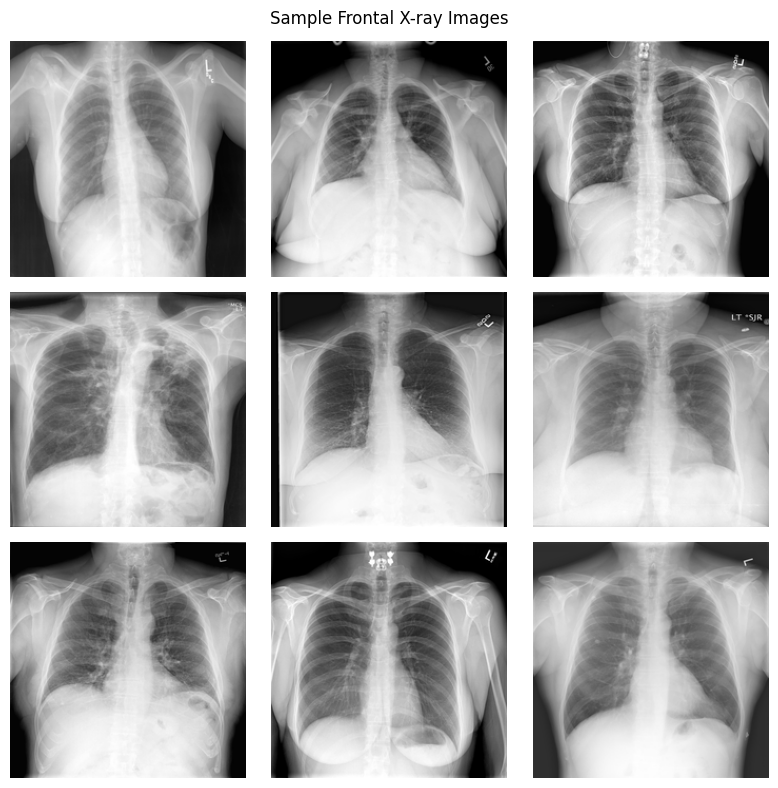

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    img_data = data[i]["img_frontal_processed"]
    if isinstance(img_data, dict) and "bytes" in img_data:
        img = Image.open(io.BytesIO(img_data["bytes"]))
    else:
        img = img_data

    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.suptitle("Sample Frontal X-ray Images")
plt.tight_layout()
plt.show()

The sample frontal X-ray images show consistent anatomical structures, including clear lung fields, rib boundaries, and heart silhouettes.

There is visible variability across samples, with some images showing potential abnormalities such as opacities or asymmetry, suggesting the dataset contains both normal and pathological cases.

The images are centered and aligned, indicating successful preprocessing and suitability for downstream modeling.

In [ ]:
sizes = []

for i in range(len(data)):
    img_data = data[i]["img_frontal_processed"]
    if isinstance(img_data, dict) and "bytes" in img_data:
        img = Image.open(io.BytesIO(img_data["bytes"]))
    else:
        img = img_data
    sizes.append(img.size)

set(sizes)

{(224, 224)}

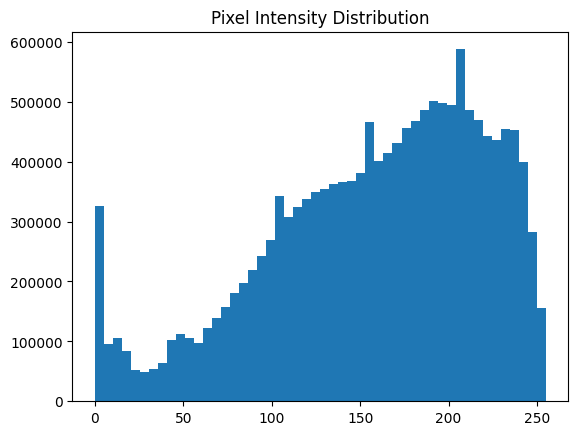

In [ ]:
pixels = []

for i in range(100):
    img_data = data[i]["img_frontal_processed"]
    if isinstance(img_data, dict) and "bytes" in img_data:
        img = Image.open(io.BytesIO(img_data["bytes"]))
    else:
        img = img_data

    img_arr = np.array(img)
    pixels.extend(img_arr.flatten())

plt.hist(pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()

The pixel intensity distribution spans the full grayscale range (0–255), indicating that the images preserve sufficient contrast information.

The distribution is skewed toward higher intensity values, which is expected in chest X-rays due to large bright regions such as bones and background areas.

The absence of extreme spikes or degenerate distributions suggests that the images are not corrupted and have been properly normalized.

In [ ]:
means = []
for i in range(100):
    img_data = data[i]["img_frontal_processed"]
    if isinstance(img_data, dict) and "bytes" in img_data:
        img = Image.open(io.BytesIO(img_data["bytes"]))
    else:
        img = img_data

    img_arr = np.array(img)
    means.append(img_arr.mean())

print(np.mean(means), np.std(means))

158.0097532684949 16.440003014495094


The average pixel intensity across sampled images is approximately 158 with a standard deviation of 16.4.

The relatively high mean intensity reflects the presence of bright regions such as bones and background in chest X-ray images.

The low standard deviation suggests that pixel intensity is consistent across samples, indicating stable preprocessing and uniform image quality.

This consistency is beneficial for model training, suggesting that the dataset is well-normalized, as it reduces variability unrelated to underlying pathology.

### 2.1.2 Multi-View Comparison

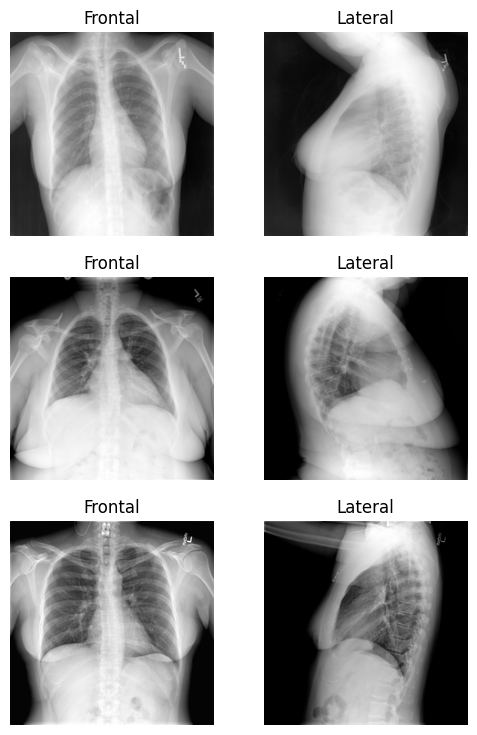

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(6, 9))

for i in range(3):
    # Frontal
    img_f = data[i]["img_frontal_processed"]
    if isinstance(img_f, dict) and "bytes" in img_f:
        img_f = Image.open(io.BytesIO(img_f["bytes"]))

    axes[i, 0].imshow(img_f, cmap="gray")
    axes[i, 0].set_title("Frontal")
    axes[i, 0].axis("off")

    # Lateral
    img_l = data[i]["img_lateral_processed"]
    if isinstance(img_l, dict) and "bytes" in img_l:
        img_l = Image.open(io.BytesIO(img_l["bytes"]))

    axes[i, 1].imshow(img_l, cmap="gray")
    axes[i, 1].set_title("Lateral")
    axes[i, 1].axis("off")

plt.show()

Each sample contains both frontal and lateral views, providing complementary perspectives of the chest.

While frontal images capture the overall lung structure, lateral views provide additional depth information that may help identify abnormalities not visible in a single view.

This multi-view setup suggests potential for multimodal or multi-input modeling approaches.

### 2.1.3 Summary

Overall, the image data appears clean, standardized, and suitable for CNN-based modeling, with sufficient variability to capture clinically relevant patterns.

## 2.2 Text EDA

In [ ]:
# #Text Preprocess completed -> ds_cleaned
# from datasets import load_from_disk
# from google.colab import drive
# drive.mount('/content/drive')
# # ds_cleaned = load_from_disk("/content/drive/MyDrive/cs109b_project/ds_cleaned.zip")
# # zip_file_path = "/content/drive/MyDrive/cs109b_project/ds_cleaned.zip"
# # extraction_path = "/content/drive/MyDrive/cs109b_project"
# # !unzip -q "{zip_file_path}" -d "{extraction_path}"


df = dataset.to_pandas()
print(f"Total samples: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

Total samples: 3388
Columns: ['uid', 'MeSH', 'Problems', 'image', 'indication', 'comparison', 'findings', 'impression', 'img_frontal', 'img_lateral', 'img_frontal_processed', 'img_lateral_processed', 'is_valid', 'findings_refined', 'impression_refined', 'findings_wc', 'impression_wc', 'xxxx_findings', 'xxxx_impression']


### 2.2.1 Text Overview

In [ ]:
def word_count(text):
    if text is None or str(text).strip() == "":
        return 0
    return len(str(text).strip().split())

In [ ]:

df["findings_wc"]   = df["findings_refined"].apply(word_count)
df["impression_wc"] = df["impression_refined"].apply(word_count)

print("=== Text Column Summary ===")
summary = pd.DataFrame({
    "column": ["findings_refined", "impression_refined"],
    "total": [len(df), len(df)],
    "non_empty": [(df["findings_wc"] > 0).sum(), (df["impression_wc"] > 0).sum()],
    "missing": [(df["findings_wc"] == 0).sum(), (df["impression_wc"] == 0).sum()],
    "mean_words":[df[df["findings_wc"] > 0]["findings_wc"].mean().round(1),
                  df[df["impression_wc"] > 0]["impression_wc"].mean().round(1)],
    "median_words": [df[df["findings_wc"]  > 0]["findings_wc"].median(),
                    df[df["impression_wc"] > 0]["impression_wc"].median()],
    "max_words": [df["findings_wc"].max(), df["impression_wc"].max()],
})

print(summary.to_string(index=False))

=== Text Column Summary ===
            column  total  non_empty  missing  mean_words  median_words  max_words
  findings_refined   3388       2943      445        31.0          29.0        149
impression_refined   3388       3370       18        10.1           5.0        133


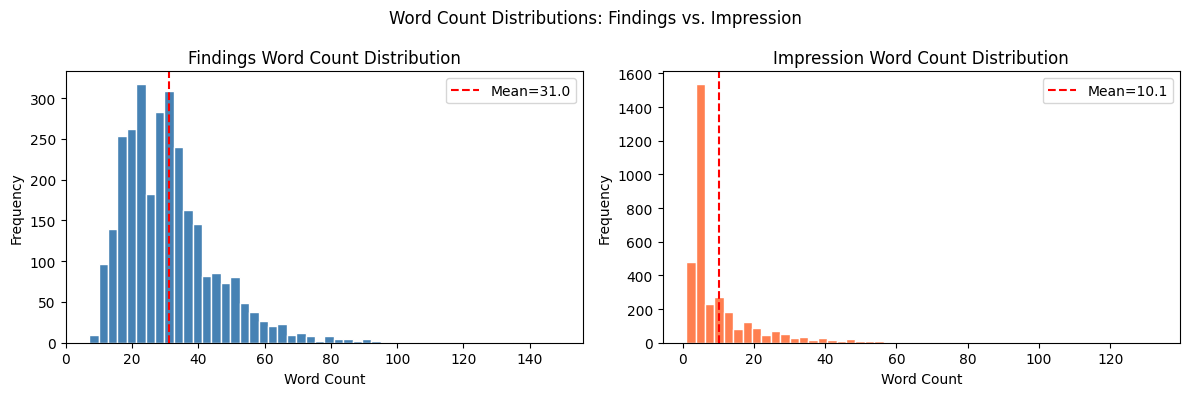

In [ ]:
findings_mean = df[df["findings_wc"] > 0]["findings_wc"].mean()
impression_mean = df[df["impression_wc"] > 0]["impression_wc"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[df["findings_wc"] > 0]["findings_wc"], bins=50,
             color="steelblue", edgecolor="white")
axes[0].set_title("Findings Word Count Distribution")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")
axes[0].axvline(findings_mean, color="red", linestyle="--", label=f"Mean={findings_mean:.1f}")
axes[0].legend()

axes[1].hist(df[df["impression_wc"] > 0]["impression_wc"], bins=50,
             color="coral", edgecolor="white")
axes[1].set_title("Impression Word Count Distribution")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].axvline(impression_mean, color="red", linestyle="--", label=f"Mean={impression_mean:.1f}")
axes[1].legend()

plt.suptitle("Word Count Distributions: Findings vs. Impression")
plt.tight_layout()
plt.show()

For the two description columns that could potentially be used as the generation ground-truth, 'findings' and 'impression', in the cleaned dataset, which has also been stripped of numbering, the summary and distributions above reveal some key insights. The findings word count distribution is approximately bell-shaped, centered around its mean of 31 words (among only non-empty samples) with a modest right tail extending to 100 words, indicating that findings are consistently verbose across samples. In contrast, the impression distribution is heavily right-skewed as the tallest bar sits near 0-5 words with frequency exceeding 1,500, dropping sharply afterward, confirming that the vast majority of impressions are very short single-sentence conclusions while a small subset of pathological cases produce notably longer multi-finding outputs that pull the mean up to 10.1.

More importantly, findings has 445 missing values (13%) compared to only 18 (0.5%) for impression. This missingness in findings is not addressed by the image-based filtering applied in preprocessing, where samples were only filtered on image validity, not text completeness.  As a result, using findings as a generation target would either discard 13% of the dataset or require imputation.

These observations jointly motivate using impression as the generation target for out redefined task as it is more complete, more concise and structured, and clinically more meaningful as the radiologist's final actionable conclusion.

In [ ]:
missing_matrix = pd.DataFrame({
    "findings_missing": df["findings_wc"] == 0,
    "impression_missing": df["impression_wc"] == 0,
})

print(f"\nMissing findings but have impression: "
      f"{(missing_matrix['findings_missing'] & ~missing_matrix['impression_missing']).sum()}")
print(f"Missing both: "
      f"{(missing_matrix['findings_missing'] & missing_matrix['impression_missing']).sum()}")


Missing findings but have impression: 433
Missing both: 12


Of the 445 samples missing findings, 433 (97.3%) still have a valid impression, and only 12 samples are missing both. This confirms that impression is a far more reliable target column as it is present even when findings are absent, suggesting that radiologists prioritized writing the
clinical conclusion over the detailed observations in some cases. This further solidifies the choice of impression as the generation target.

In [ ]:
numbered = df[df["impression"].str.contains(r'^\s*1[\.\)]', na=False, regex=True)]
print(f"Total numbered impressions: {len(numbered)}")
print(numbered[["impression", "impression_refined"]][2:3].to_string())

Total numbered impressions: 655
                                                                                                                                                                                                                                                                           impression                                                                                                                                                                                                                                                               impression_refined
27  1. Interval improvement in consolidative left base opacity. Multifocal scattered bibasilar patchy and XXXX pulmonary opacities again noted, most consistent with atelectasis/infiltrate. 2. Stable enlarged cardiomediastinal silhouette. Stable pulmonary vascular congestion. .  Interval improvement in consolidative left base opacity. Multifocal scattered bibasilar patchy and XXXX pulmonary opacities again noted, m

One limitation of the current text preprocessing is the inconsistent use of '[SEP]' tag across samples. Approximately 19% of impression originally contained numbered findings (e.g., "1. Cardiomegaly. 2. Pleural effusion."), corresponding to samples where radiologists originally enumerated multiple distinct findings, which were converted to '[SEP]'-delimited boundaries during preprocessing. The remaining impressions contain a single finding and therefore require no separator. This means '[SEP]' is semantically meaningful where present, but its absence simply indicates a single-finding impression. The primary open question for following training is whether to retain '[SEP]' as a special token or normalize to flat text, depending on the final model architecture chosen.

### 2.2.2 XXXX Tokens

In [ ]:
def count_xxxx(text):
    if text is None:
        return 0
    return len(re.findall(r'XXXX', str(text), re.IGNORECASE))

df["xxxx_findings"] = df["findings_refined"].apply(count_xxxx)
df["xxxx_impression"] = df["impression_refined"].apply(count_xxxx)

print("=== XXXX Token Summary ===")
print(f"Samples with XXXX in findings: {(df['xxxx_findings'] > 0).sum()} "
      f"({(df['xxxx_findings'] > 0).mean():.1%})")
print(f"Samples with XXXX in impression: {(df['xxxx_impression'] > 0).sum()} "
      f"({(df['xxxx_impression'] > 0).mean():.1%})")
print(f"\nMean XXXX per findings sample: {df[df['xxxx_findings']   > 0]['xxxx_findings'].mean():.2f}")
print(f"Mean XXXX per impression sample: {df[df['xxxx_impression'] > 0]['xxxx_impression'].mean():.2f}")

=== XXXX Token Summary ===
Samples with XXXX in findings: 1220 (36.0%)
Samples with XXXX in impression: 548 (16.2%)

Mean XXXX per findings sample: 1.65
Mean XXXX per impression sample: 1.76


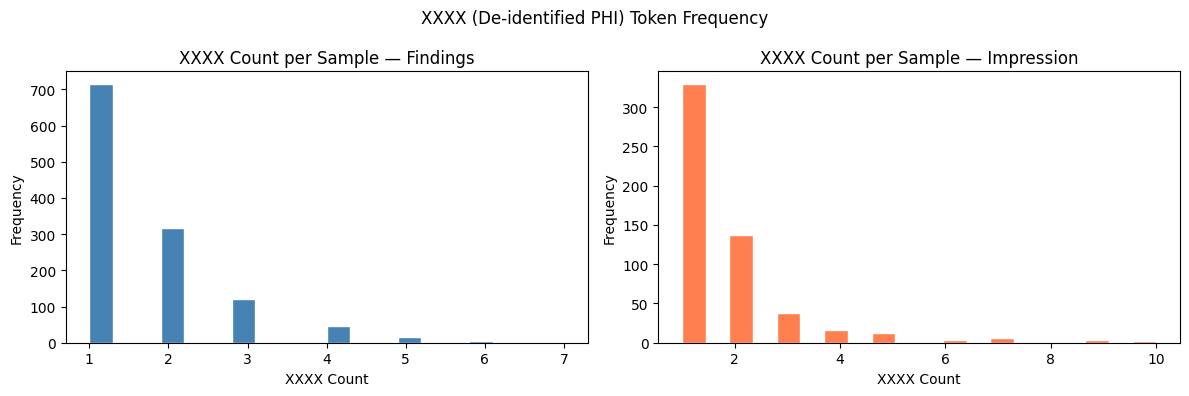

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df[df["xxxx_findings"] > 0]["xxxx_findings"], bins=20,
             color="steelblue", edgecolor="white")
axes[0].set_title("XXXX Count per Sample — Findings")
axes[0].set_xlabel("XXXX Count")
axes[0].set_ylabel("Frequency")

axes[1].hist(df[df["xxxx_impression"] > 0]["xxxx_impression"], bins=20,
             color="coral", edgecolor="white")
axes[1].set_title("XXXX Count per Sample — Impression")
axes[1].set_xlabel("XXXX Count")
axes[1].set_ylabel("Frequency")

plt.suptitle("XXXX (De-identified PHI) Token Frequency")
plt.tight_layout()
plt.show()

XXXX tokens serve as placeholders for de-identified protected health information (PHI), such as patient names, ages, and dates, appearing in 36% of findings samples and 16% of impression samples. The higher prevalance in findings is expected since findings are more verbose and more likely to reference patient-specific contextual information.

Both distributions are heavily concentrated at low counts (1-2 XXXX tokens per sample), with frequency dropping sharply beyond that. Findings extend up to 7 XXXX tokens while impressions reach up to 10, though these high counts are extremely rare.

For model training, XXXX tokens in the target (impression) can be problematic as the model would need to learn to generate XXXX as an output token, which is meaningless and potentially misleading. A practical decision would be to strip XXXX from impression targets entirely before training, or replace them with a generic placeholder the tokenizer natively supports.

In [ ]:
def get_corpus(series):
    all_text = " ".join([str(x) for x in series.dropna() if word_count(x) > 0])
    # remove XXXX and SEP tokens for vocabulary analysis
    all_text = re.sub(r'XXXX', '', all_text, flags=re.IGNORECASE)
    all_text = re.sub(r'\[SEP\]', '', all_text)
    return all_text

def vocab_size(text):
    words = re.findall(r'\b[a-z]{2,}\b', text.lower())
    return len(set(words)), len(words)

In [ ]:
findings_text = get_corpus(df["findings_refined"])
impression_text = get_corpus(df["impression_refined"])

findings_unique, findings_total = vocab_size(findings_text)
impression_unique, impression_total = vocab_size(impression_text)

print("=== Vocabulary Summary ===")
print(f"Findings — unique tokens: {findings_unique:,}, total tokens: {findings_total:,}")
print(f"Impression — unique tokens: {impression_unique:,}, total tokens: {impression_total:,}")

=== Vocabulary Summary ===
Findings — unique tokens: 1,475, total tokens: 88,661
Impression — unique tokens: 1,384, total tokens: 32,632


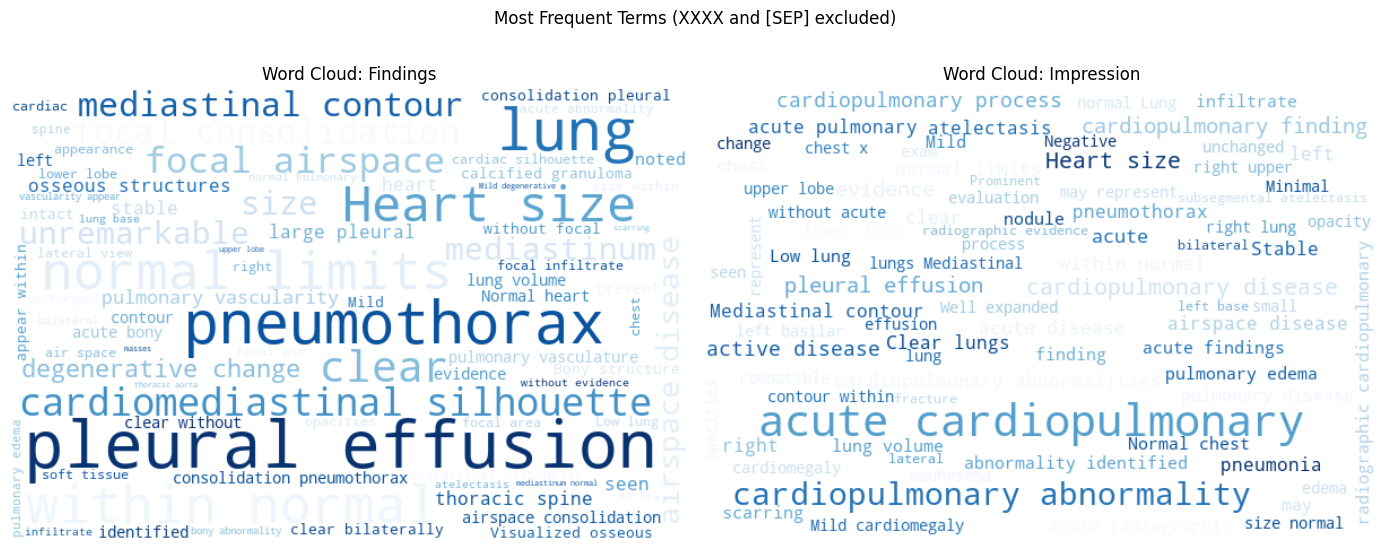

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, text, title in zip(axes,
                            [findings_text, impression_text],
                            ["Findings", "Impression"]):
    wc = WordCloud(width=600, height=400,
                   background_color="white",
                   colormap="Blues",
                   max_words=80).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Word Cloud: {title}")

plt.suptitle("Most Frequent Terms (XXXX and [SEP] excluded)")
plt.tight_layout()
plt.show()

The vocabulary analysis reveals clear differences in language style between the two text columns. Findings uses 1,475 unique tokens across 88,661 total tokens, while impression uses 1,384 unique tokens across only 32,632 total tokens. Despite having a similar vocabulary size, impression uses far fewer total words， confirming its concise, formulaic nature.

The word clouds further illustrate this contrast. Findings vocabulary is dominated by specific anatomical descriptors and observations: "pleural effusion", "pneumothorax", "focal consolidation", "cardiomediastinal silhouette", and "osseous structures" — detailed radiological observations
that describe what is seen in the image. In contrast, impression vocabulary centers around conclusive clinical language: "acute cardiopulmonary", "cardiopulmonary abnormality", "clear lungs", "heart size", and "pleural effusion", which are shorter, more standardized phrases that summarize the bottom-line clinical conclusion.

This distinction is important for model training. The impression vocabulary is smaller and more formulaic, meaning the generation model needs to learn a more constrained output space compared to findings. The high frequency of phrases like "no acute cardiopulmonary process" and "clear lungs" in the impression cloud also visually confirms the class imbalance noted earlier: a large proportion of impressions describe normal or unremarkable findings, which the model will need to handle carefully to avoid defaulting to generic normal outputs for all inputs.

## 2.3 Extended EDA: Pretrained Medical LLM Review of Image–Text Pairs

As an extended EDA step, we may sample a small subset of frontal and lateral chest X-ray studies and compare the outputs of a general-purpose or medical vision-language model with the dataset’s `impression_refined` field, which is the cleaned and standardized target text selected for our project. The purpose of this comparison is not to generate new labels, but to assess whether the image patterns recognized by the vision-language model are broadly consistent with the short clinical summaries already present in the dataset. Because `impression_refined` is shorter, cleaner, and more complete than `findings`, it provides the most appropriate reference for this qualitative sanity check.

Since we do not have access to a radiologist, this step will be used only as supplementary evidence for image-text consistency and task validity, not as formal supervision, feature engineering, or final model evaluation.

As a supplementary extended EDA step, we plan to use **CheXagent** (https://github.com/Stanford-AIMI/CheXagent?tab=readme-ov-file), a pretrained chest X-ray vision-language model from Stanford AIMI, to qualitatively inspect a small sample of our cleaned frontal and lateral studies.

The CheXagent repository describes it as a foundation model for chest X-ray interpretation and provides built-in functions for tasks such as disease identification, findings generation, image-text matching, and findings summarization, which makes it a good fit for our exploratory image–text consistency check. In our project, we will not use CheXagent as a source of new labels or formal supervision. Instead, we will compare its qualitative outputs with our dataset’s impression_refined field on a small sample to see whether the model identifies broadly consistent radiographic patterns, providing a sanity check on the validity of the image–text pairs and the feasibility of our revised image-to-impression task. CheXagent is provided for research purposes only, so this step will remain purely exploratory.

In [ ]:
# make sure to restart session after you downgrade the transformers
# !pip uninstall -y transformers
# !pip install -q transformers==4.39.0 accelerate opencv-python albumentations sentencepiece protobuf

In [ ]:
print(transformers.__version__)

4.39.0


In [ ]:
model_name = "StanfordAIMI/CheXagent-2-3b-srrg-impression"
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32


# 2. Load model

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    trust_remote_code=True
)
model = model.to(dtype)
model.eval()


# 3. Make temp folder for images

os.makedirs("chexagent_temp", exist_ok=True)



tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenization_chexagent.py: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/711 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

### 2.3.1 Run and test One sample

This step tests the pretrained medical vision-language model on a single chest X-ray study before scaling to multiple samples. By comparing the generated output with the dataset’s impression_refined label, we can first check whether the model produces a clinically reasonable and broadly aligned summary. This serves as an initial sanity check for image–text consistency in our cleaned dataset.


In [ ]:

# 4. Function: run one sample

def run_chexagent_on_sample(dataset, idx, prompt="Structured Radiology Report Generation for Impression Section",
                            ref = "impression_refined"):
    # Support both pandas DataFrame and HuggingFace dataset indexing
    sample = dataset.iloc[idx] if isinstance(dataset, pd.DataFrame) else dataset[idx]

    frontal_img = sample["img_frontal_processed"]
    if isinstance(frontal_img, dict) and "bytes" in frontal_img:
        frontal_img = Image.open(io.BytesIO(frontal_img["bytes"]))

    lateral_img = sample["img_lateral_processed"]
    if isinstance(lateral_img, dict) and "bytes" in lateral_img:
        lateral_img = Image.open(io.BytesIO(lateral_img["bytes"]))

    frontal_path = f"chexagent_temp/sample_{idx}_frontal.png"
    lateral_path = f"chexagent_temp/sample_{idx}_lateral.png"

    frontal_img.save(frontal_path)
    lateral_img.save(lateral_path)

    paths = [frontal_path, lateral_path]

    query = tokenizer.from_list_format(
        [*[{"image": path} for path in paths], {"text": prompt}]
    )

    conv = [
        {"from": "system", "value": "You are a helpful assistant."},
        {"from": "human", "value": query}
    ]

    model_inputs = tokenizer.apply_chat_template(
        conv,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True
    )

    model_inputs = {k: v.to(device) for k, v in model_inputs.items()}

    output = model.generate(
        **model_inputs,
        do_sample=False,
        num_beams=1,
        max_new_tokens=64,
        pad_token_id=tokenizer.eos_token_id,
        use_cache=True
    )[0]

    input_len = model_inputs["input_ids"].shape[1]
    response = tokenizer.decode(
        output[input_len:],
        skip_special_tokens=True
    ).strip()

    return {
        "uid": sample["uid"],
        "generated_impression": response,
        "reference_impression": sample[ref]
    }



In [ ]:
# 5. Test one sample

result = run_chexagent_on_sample(dataset, 1, prompt = "Generate a one- to two-sentence radiology impression for this chest X-ray study. Be concise and do not produce findings or explanation.")

print("UID:", result["uid"])
print("\nCheXagent output:")
print(result["generated_impression"])
print("\nReference impression_refined:")
print(result["reference_impression"])

UID: 2

CheXagent output:
1. No evidence of acute cardiopulmonary disease.
2. No evidence of pneumonia.

Reference impression_refined:
No acute pulmonary findings.


In this example, CheXagent generated a more detailed impression than the dataset reference, but both outputs were clinically consistent in indicating no acute cardiopulmonary abnormality. The main difference is that the model explicitly listed several negative findings and mentioned stable post-surgical changes, while the reference impression remained shorter and more concise.

### 2.3.2 Run and test  10 samples
This step extends the initial single-sample check by running CheXagent on 10 sampled studies and comparing the generated summaries with the dataset’s `impression_refined` labels. To make the comparison more systematic, we also visualize BLEU, ROUGE-1, and ROUGE-L scores across samples as supporting metrics.

In [ ]:
# !pip install -q rouge_score

# 1. normalize text
def normalize_for_eval(text):
    if text is None:
        return ""
    text = str(text).lower()
    text = re.sub(r'xxxx', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\[sep\]', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# 2. compute metrics
def compute_text_metrics(generated_text, reference_text):
    gen = normalize_for_eval(generated_text)
    ref = normalize_for_eval(reference_text)

    smoothie = SmoothingFunction().method1
    bleu = sentence_bleu(
        [ref.split()],
        gen.split(),
        smoothing_function=smoothie
    )

    scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)
    rouge_scores = scorer.score(ref, gen)

    return {
        "bleu": bleu,
        "rouge1_f1": rouge_scores["rouge1"].fmeasure,
        "rougeL_f1": rouge_scores["rougeL"].fmeasure,
        "gen_len": len(gen.split()),
        "ref_len": len(ref.split())
    }

# 3. unified evaluator
def evaluate_on_df(df, generate_fn, model_name="model"):
    results = []

    for idx, row in df.iterrows():
        uid = row["uid"]
        ref = row["reference_text"]

        try:
            gen = generate_fn(row)
            metrics = compute_text_metrics(gen, ref)

            results.append({
                "idx": idx,
                "uid": uid,
                "model": model_name,
                "generated_impression": gen,
                "reference_impression": ref,
                **metrics
            })

        except Exception as e:
            results.append({
                "idx": idx,
                "uid": uid,
                "model": model_name,
                "generated_impression": f"ERROR: {e}",
                "reference_impression": ref,
                "bleu": None,
                "rouge1_f1": None,
                "rougeL_f1": None,
                "gen_len": None,
                "ref_len": None
            })

    return pd.DataFrame(results)


In [ ]:
# 4. build smoke_df
n_samples = 10
ref_text = "impression_refined"
smoke_df = df.sample(n=n_samples, random_state=109).copy().reset_index(drop=True)
smoke_df["reference_text"] = smoke_df[ref_text]
prompt = "Generate a one- to two-sentence radiology impression for this chest X-ray study. Be concise and do not produce findings or explanation."

# 5. wrap Stanford model
def stanford_generate_fn(row):
    idx = row.name
    out = run_chexagent_on_sample(smoke_df, idx, prompt = prompt)
    return out["generated_impression"]

# 6. run smoke test
compare_df = evaluate_on_df(
    smoke_df,
    generate_fn=stanford_generate_fn,
    model_name="stanford_model"
)

compare_df

,idx,uid,model,generated_impression,reference_impression,bleu,rouge1_f1,rougeL_f1,gen_len,ref_len
0,0,441,stanford_model,1. No evidence of acute cardiopulmonary diseas...,No acute cardiopulmonary abnormality.,0.017730,0.206897,0.206897,25,4
1,1,1294,stanford_model,1. No evidence of pneumothorax.\n2. No acute c...,No active disease.,0.018850,0.285714,0.285714,11,3
2,2,2070,stanford_model,1. No evidence of acute cardiopulmonary diseas...,"Subtle interstitial markings bilateral, may re...",0.006980,0.050000,0.050000,27,13
3,3,2236,stanford_model,1. No evidence of acute cardiopulmonary diseas...,Unremarkable chest x-XXXX.,0.000000,0.000000,0.000000,17,3
4,4,3925,stanford_model,1. No evidence of acute cardiopulmonary diseas...,No acute pulmonary disease.,0.012022,0.240000,0.240000,21,4
5,5,1730,stanford_model,1. No evidence of acute cardiopulmonary diseas...,No acute cardiopulmonary abnormalities.,0.015146,0.181818,0.181818,29,4
6,6,3287,stanford_model,1. Presence of a retrocardiac opacity on the l...,Right midlung and left basilar airspace densit...,0.006938,0.076923,0.038462,32,21
7,7,1414,stanford_model,1. No evidence of acute cardiopulmonary diseas...,Heart size normal. Lungs clear. Resolution of ...,0.012301,0.142857,0.142857,16,12
8,8,3767,stanford_model,1. No evidence of acute cardiopulmonary diseas...,"Heart size, mediastinal silhouette, pulmonary ...",0.013636,0.324324,0.216216,17,20
9,9,1094,stanford_model,1. Resolution of previously noted right pleura...,No focal lung consolidation.,0.013218,0.105263,0.105263,15,4


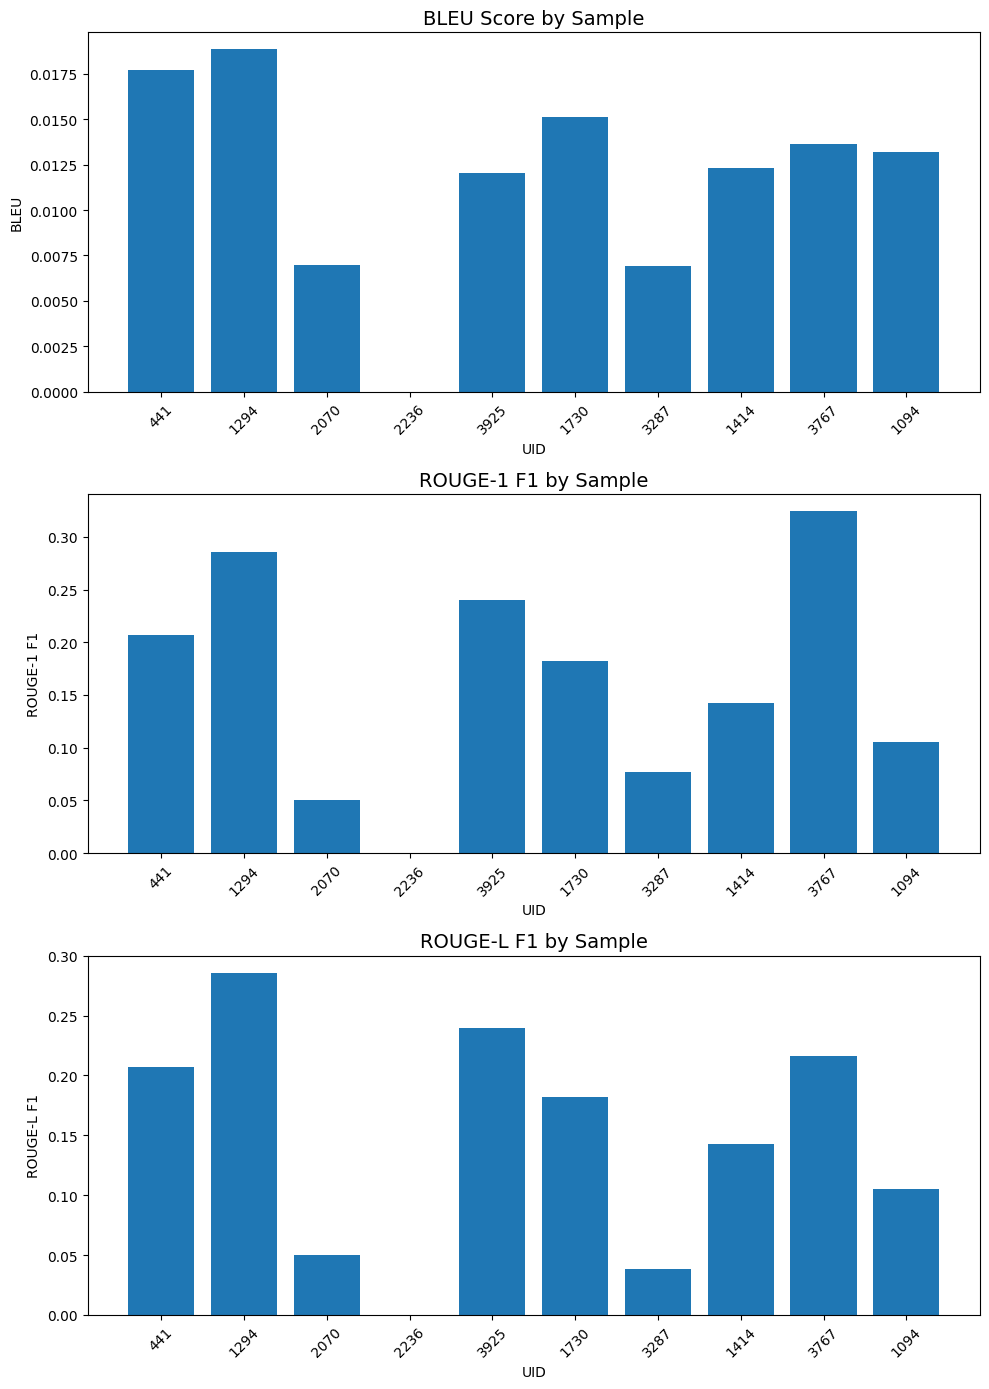

In [ ]:
plot_df = compare_df.dropna(subset=["bleu", "rouge1_f1", "rougeL_f1"]).copy()

fig, axes = plt.subplots(3, 1, figsize=(10, 14))

axes[0].bar(plot_df["uid"].astype(str), plot_df["bleu"])
axes[0].set_title("BLEU Score by Sample", fontsize=14)
axes[0].set_xlabel("UID")
axes[0].set_ylabel("BLEU")
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(plot_df["uid"].astype(str), plot_df["rouge1_f1"])
axes[1].set_title("ROUGE-1 F1 by Sample", fontsize=14)
axes[1].set_xlabel("UID")
axes[1].set_ylabel("ROUGE-1 F1")
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(plot_df["uid"].astype(str), plot_df["rougeL_f1"])
axes[2].set_title("ROUGE-L F1 by Sample", fontsize=14)
axes[2].set_xlabel("UID")
axes[2].set_ylabel("ROUGE-L F1")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Across the 10 sampled studies, CheXagent outputs were generally broadly clinically consistent with `impression_refined`, but they were often more detailed than the reference labels. This led to relatively low BLEU scores but moderately higher ROUGE-1 and ROUGE-L scores, suggesting limited exact wording overlap but partial content overlap.

In many cases, both the model and the dataset label agreed on the main conclusion, such as the absence of acute cardiopulmonary abnormality, even when the model listed additional negative findings or chronic details not included in the reference.

One notable exception was the sample with all-zero BLEU and ROUGE scores, which indicates no lexical overlap at all; however, this likely reflects a strong wording mismatch, extra detail, and label artifacts such as `XXXX`, rather than automatically implying clinical disagreement. Overall, these results support that `impression_refined` is a meaningful and usable target label for the revised task, while also showing that automatic overlap metrics should be interpreted cautiously because semantic agreement can still exist even when lexical similarity is very low. They also suggest that artifacts such as `XXXX` should be explicitly handled in the feature engineering stage, since they can distort text overlap metrics and introduce noise into the target representation without adding meaningful clinical information.

### 2.3.3 BERTScore

While BLEU and ROUGE have been widely adopted as automatic evaluation metrics for natural language generation tasks, they rely on surface-level n-gram overlap between the generated text and reference text, making them sensitive to exact word matches and largely insensitive to semantic equivalence. In the context of radiology report generation, this is a notable limitation: clinically synonymous expressions such as "No acute cardiopulmonary abnormalities detected." and "No acute cardiopulmonary findings." convey identical diagnostic meaning yet would receive low overlap scores under these metrics. As a result, BLEU and ROUGE may underestimate the quality of generated impressions that are semantically accurate but lexically diverse.

To address this limitation, we additionally adopt BERTScore as a complementary evaluation metric. BERTScore leverages contextual embeddings from a pre-trained BERT model to compute token-level similarity between the generated and reference texts. Specifically, it matches each token in the candidate sentence to the most similar token in the reference sentence using cosine similarity in the embedding space, and aggregates these scores into precision, recall, and F1 values. By operating in a dense semantic space rather than relying on discrete token overlap, BERTScore is better equipped to capture meaning-preserving paraphrases and domain-specific linguistic variation, making it a more clinically sensitive measure for evaluating generated radiology impressions.

In [ ]:
def compute_text_metrics(generated_text, reference_text):
    gen = normalize_for_eval(generated_text)
    ref = normalize_for_eval(reference_text)

    smoothie = SmoothingFunction().method1
    bleu = sentence_bleu(
        [ref.split()],
        gen.split(),
        smoothing_function=smoothie
    )

    scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)
    rouge_scores = scorer.score(ref, gen)

    # Calculate BERTScore
    P, R, F1 = score([gen], [ref], lang="en", verbose=False)

    return {
        "bleu": bleu,
        "rouge1_f1": rouge_scores["rouge1"].fmeasure,
        "rougeL_f1": rouge_scores["rougeL"].fmeasure,
        "bertscore_p": P.item(),
        "bertscore_r": R.item(),
        "bertscore_f1": F1.item(),
        "gen_len": len(gen.split()),
        "ref_len": len(ref.split())
    }

In [ ]:
n_samples = 10
ref_text = "impression_refined"
smoke_df = df.sample(n=n_samples, random_state=109).copy().reset_index(drop=True)
smoke_df["reference_text"] = smoke_df[ref_text]

def stanford_generate_fn(row):
    idx = row.name
    out = run_chexagent_on_sample(smoke_df, idx, prompt = prompt, ref = ref_text)
    return out["generated_impression"]

compare_df = evaluate_on_df(
    smoke_df,
    generate_fn=stanford_generate_fn,
    model_name="stanford_model"
)

compare_df

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

,idx,uid,model,generated_impression,reference_impression,bleu,rouge1_f1,rougeL_f1,bertscore_p,bertscore_r,bertscore_f1,gen_len,ref_len
0,0,441,stanford_model,1. No evidence of acute cardiopulmonary diseas...,No acute cardiopulmonary abnormality.,0.017730,0.206897,0.206897,0.838375,0.928064,0.880942,25,4
1,1,1294,stanford_model,1. No evidence of pneumothorax.\n2. No acute c...,No active disease.,0.018850,0.285714,0.285714,0.831465,0.897285,0.863122,11,3
2,2,2070,stanford_model,1. No evidence of acute cardiopulmonary diseas...,"Subtle interstitial markings bilateral, may re...",0.006980,0.050000,0.050000,0.830411,0.849977,0.840080,27,13
3,3,2236,stanford_model,1. No evidence of acute cardiopulmonary diseas...,Unremarkable chest x-XXXX.,0.000000,0.000000,0.000000,0.814566,0.796904,0.805638,17,3
4,4,3925,stanford_model,1. No evidence of acute cardiopulmonary diseas...,No acute pulmonary disease.,0.012022,0.240000,0.240000,0.837960,0.911954,0.873392,21,4
5,5,1730,stanford_model,1. No evidence of acute cardiopulmonary diseas...,No acute cardiopulmonary abnormalities.,0.015146,0.181818,0.181818,0.845685,0.935574,0.888362,29,4
6,6,3287,stanford_model,1. Presence of a retrocardiac opacity on the l...,Right midlung and left basilar airspace densit...,0.006938,0.076923,0.038462,0.831066,0.831687,0.831377,32,21
7,7,1414,stanford_model,1. No evidence of acute cardiopulmonary diseas...,Heart size normal. Lungs clear. Resolution of ...,0.012301,0.142857,0.142857,0.850276,0.870809,0.860420,16,12
8,8,3767,stanford_model,1. No evidence of acute cardiopulmonary diseas...,"Heart size, mediastinal silhouette, pulmonary ...",0.013636,0.324324,0.216216,0.898777,0.866557,0.882372,17,20
9,9,1094,stanford_model,1. Resolution of previously noted right pleura...,No focal lung consolidation.,0.013218,0.105263,0.105263,0.860582,0.887596,0.873880,15,4


# 3.Feature engineering

We have already completed the main preprocessing and EDA steps needed to clean and understand both the image and text portions of the dataset. In particular, we identified `impression_refined` as the most appropriate target text because it is shorter, cleaner, and more complete than findings, while also finding that special artifacts such as `XXXX` and `[SEP]` remain in a subset of samples. The next feature-engineering step is therefore to refine this target text further by deciding how to handle these artifacts so that the model learns clinically meaningful language rather than formatting or de-identification noise.

### 3.1 Removing xxxx

As the first feature-engineering step, we further refine the target text by removing `XXXX` tokens from `impression_refined`. As in previous part we found These tokens are de-identification placeholders rather than meaningful clinical content, so keeping them would add noise to the target text and could distort both training and evaluation. We therefore create a new column, `impression_final`, where `XXXX` is removed and spacing is cleaned again.

In [ ]:
def remove_xxxx(text):
    if text is None:
        return None
    text = str(text)
    text = re.sub(r'XXXX', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

ds_cleaned = dataset.map(
    lambda x: {"impression_final": remove_xxxx(x["impression_refined"])}
)

In [ ]:
check_df = ds_cleaned.select(range(10)).to_pandas()[
    ["uid", "impression_refined", "impression_final"]
]
check_df

,uid,impression_refined,impression_final
0,1,Normal chest x-XXXX.,Normal chest x-.
1,2,No acute pulmonary findings.,No acute pulmonary findings.
2,3,"No displaced rib fractures, pneumothorax, or p...","No displaced rib fractures, pneumothorax, or p..."
3,4,Bullous emphysema and interstitial fibrosis. [...,Bullous emphysema and interstitial fibrosis. [...
4,5,No acute cardiopulmonary abnormality.,No acute cardiopulmonary abnormality.
5,6,No acute cardiopulmonary findings.,No acute cardiopulmonary findings.
6,7,Basilar atelectasis. No confluent lobar consol...,Basilar atelectasis. No confluent lobar consol...
7,8,No acute cardiopulmonary disease.,No acute cardiopulmonary disease.
8,9,Increased size of density in the left cardioph...,Increased size of density in the left cardioph...
9,10,No acute cardiopulmonary process.,No acute cardiopulmonary process.


We removed `XXXX` tokens from the target text!

### 3.2 Handling [SEP]
After removing `XXXX`, the next feature-engineering step is to handle `[SEP]` in the target text. In our cleaned dataset, `[SEP]` was introduced during preprocessing to preserve the structure of numbered multi-finding impressions. For the first baseline, we convert `[SEP]` into normal punctuation so that the target text remains clinically meaningful while becoming more natural for sequence generation.

In [ ]:

def normalize_sep(text, sep_replacement=". "):
    if text is None:
        return None
    text = str(text)
    text = re.sub(r'\[SEP\]', sep_replacement, text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'\s*\.\s*\.', '.', text)   # clean double periods
    text = re.sub(r'\s+,', ',', text)         # clean spacing before commas
    return text


ds_cleaned = ds_cleaned.map(
    lambda x: {"impression_final": normalize_sep(x["impression_final"])}
)

In [ ]:
check_df = ds_cleaned.select(range(10)).to_pandas()[
    ["uid", "impression_refined", "impression_final"]
]
check_df

,uid,impression_refined,impression_final
0,1,Normal chest x-XXXX.,Normal chest x-.
1,2,No acute pulmonary findings.,No acute pulmonary findings.
2,3,"No displaced rib fractures, pneumothorax, or p...","No displaced rib fractures, pneumothorax, or p..."
3,4,Bullous emphysema and interstitial fibrosis. [...,Bullous emphysema and interstitial fibrosis. P...
4,5,No acute cardiopulmonary abnormality.,No acute cardiopulmonary abnormality.
5,6,No acute cardiopulmonary findings.,No acute cardiopulmonary findings.
6,7,Basilar atelectasis. No confluent lobar consol...,Basilar atelectasis. No confluent lobar consol...
7,8,No acute cardiopulmonary disease.,No acute cardiopulmonary disease.
8,9,Increased size of density in the left cardioph...,Increased size of density in the left cardioph...
9,10,No acute cardiopulmonary process.,No acute cardiopulmonary process.


This step replaces `[SEP]` with normal punctuation, such as periods or semicolons, making the target text more natural and easier for the model to learn while preserving the original multi-finding content.

In [ ]:
# Load from Google Drive in the next cell
# from google.colab import drive
# drive.mount('/content/drive')
# ds_cleaned.save_to_disk("/content/drive/MyDrive/cs109b_project/ds_cleaned_final")
ds_cleaned.save_to_disk(str(NOTEBOOK_ROOT / "ds_cleaned_final"))

Our EDA and feature engineering were guided by the revised goal of generating a short, clinically plausible `impression` summary from chest X-ray images and comparing frontal-only versus **frontal + lateral input. EDA showed that the cleaned images are standardized and suitable for modeling, while `impression` is shorter, cleaner, and more complete than `findings`, making it the better target text. Based on these results, we kept the processed image fields, created a cleaner target text by removing `XXXX` and normalizing `[SEP]`, and used a pretrained medical vision-language model as a supplementary sanity check to verify that the image patterns were broadly consistent with the dataset labels. Together, these steps make the original broad report-generation task more feasible and better aligned with the structure of the cleaned dataset.

# **IMPORTANT: Transformer Version Note**

The Extended EDA section (CheXagent evaluation) above uses: **transformers==4.39.0**

From this point onward (Baseline Model and all subsequent sections), the notebook requires: **transformers>=4.51.0**

**Before running any cell below, restore the correct version by running:**

In [ ]:
#!pip uninstall -y transformers
#!pip install -q transformers==4.51.3

# Then make sure to restart the runtime before continuing.
# For this run, you should load necessary libraries again and skip the extended EDA section.

In [ ]:
print(transformers.__version__)

4.51.3


# 4.Baseline Model

### 4.1 Model motivation

We build a lightweight custom CNN encoder to extract image representations from chest X-rays. This design avoids directly relying on an off-the-shelf report generation model and provides a transparent training pipeline.

This baseline is intentionally simple and lightweight, allowing us to evaluate whether the task of generating impression summaries from images is feasible before introducing more complex models.

In [ ]:
ds_cleaned_final = load_from_disk(str(NOTEBOOK_ROOT / "ds_cleaned_final"))
df = ds_cleaned_final.to_pandas()

In [ ]:
display(df.head())

,uid,MeSH,Problems,image,indication,comparison,findings,impression,img_frontal,img_lateral,img_frontal_processed,img_lateral_processed,is_valid,findings_refined,impression_refined,findings_wc,impression_wc,xxxx_findings,xxxx_impression,impression_final
0,1,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,True,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.,34,3,1,1,Normal chest x-.
1,2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,True,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.,14,4,4,0,No acute pulmonary findings.
2,3,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",None,None,"No displaced rib fractures, pneumothorax, or p...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,True,,"No displaced rib fractures, pneumothorax, or p...",0,23,0,0,"No displaced rib fractures, pneumothorax, or p..."
3,4,"Pulmonary Disease, Chronic Obstructive;Bullous...","Pulmonary Disease, Chronic Obstructive;Bullous...","PA and lateral views of the chest XXXX, XXXX a...",XXXX-year-old XXXX with XXXX.,None available,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,True,There are diffuse bilateral interstitial and a...,Bullous emphysema and interstitial fibrosis. [...,64,46,1,0,Bullous emphysema and interstitial fibrosis. P...
4,5,Osteophyte/thoracic vertebrae/multiple/small;T...,Osteophyte;Thickening;Lung,Xray Chest PA and Lateral,Chest and nasal congestion.,None,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,True,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.,42,4,0,0,No acute cardiopulmonary abnormality.


## 4.2 frontal only, dataset split

Starting with frontal-only images provides a controlled baseline, allowing us to later assess whether adding lateral views introduces meaningful performance improvements.

In [ ]:
df_model = df[["uid", "img_frontal_processed", "impression_final", "is_valid", "MeSH"]].copy()
df_model = df_model[df_model["is_valid"] == True].copy()
df_model = df_model.dropna(subset=["img_frontal_processed", "impression_final"]).reset_index(drop=True)

In [ ]:
train_df, temp_df = train_test_split(df_model, test_size=0.2, random_state=42, shuffle=True)
valid_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, shuffle=True)

In [ ]:
train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Valid size:", len(valid_df))
print("Test size:", len(test_df))

Train size: 2710
Valid size: 339
Test size: 339


The dataset split ensures that model evaluation reflects generalization performance rather than memorization, which is especially important given the relatively limited dataset size.

### 4.2.1 Tokenization + vocab

Constructing a limited vocabulary simplifies the learning problem for the baseline model. However, this may also restrict the model’s ability to express less frequent or clinically specific terms, potentially contributing to overly generic outputs.

In [ ]:
SPECIAL_TOKENS = {
    "pad": "<pad>",
    "bos": "<bos>",
    "eos": "<eos>",
    "unk": "<unk>"
}

def simple_tokenize(text):
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text.split()

def build_vocab(texts, min_freq=2):
    counter = Counter()
    for text in texts:
        counter.update(simple_tokenize(text))

    vocab = {
        SPECIAL_TOKENS["pad"]: 0,
        SPECIAL_TOKENS["bos"]: 1,
        SPECIAL_TOKENS["eos"]: 2,
        SPECIAL_TOKENS["unk"]: 3
    }

    for word, freq in counter.items():
        if freq >= min_freq and word not in vocab:
            vocab[word] = len(vocab)

    idx_to_word = {idx: word for word, idx in vocab.items()}
    return vocab, idx_to_word

vocab, idx_to_word = build_vocab(train_df["impression_final"], min_freq=1)
pad_idx = vocab["<pad>"]
bos_idx = vocab["<bos>"]
eos_idx = vocab["<eos>"]
unk_idx = vocab["<unk>"]

print("Vocab size:", len(vocab))

Vocab size: 1865


The resulting vocabulary size is 1865, which reflects a relatively compact and standardized language space for impression summaries. This is consistent with our earlier EDA, where impression text was found to be shorter and more formulaic compared to findings.

A smaller vocabulary simplifies the learning problem for the model, allowing it to more easily capture common patterns and frequently used clinical phrases. However, this also introduces a limitation: rare or highly specific medical terms may be excluded or mapped to unknown tokens, reducing the model’s ability to generate detailed or precise descriptions.

This trade-off between simplicity and expressiveness may partially explain why the model tends to produce generic outputs, especially for abnormal cases that require more specialized vocabulary.

### 4.2.2 Check text length and set max_len

In [ ]:
lengths = train_df["impression_final"].apply(lambda x: len(simple_tokenize(x)))
print(lengths.describe())

# You can adjust this after checking the distribution
max_len = 30


def encode_text(text, vocab, max_len):
    tokens = simple_tokenize(text)
    token_ids = [vocab["<bos>"]]

    for tok in tokens:
        token_ids.append(vocab.get(tok, vocab["<unk>"]))

    token_ids.append(vocab["<eos>"])

    if len(token_ids) < max_len:
        token_ids += [vocab["<pad>"]] * (max_len - len(token_ids))
    else:
        token_ids = token_ids[:max_len]
        if token_ids[-1] != vocab["<eos>"]:
            token_ids[-1] = vocab["<eos>"]

    return token_ids

count    2710.000000
mean        9.750923
std        11.232350
min         0.000000
25%         4.000000
50%         5.000000
75%        11.000000
max       123.000000
Name: impression_final, dtype: float64


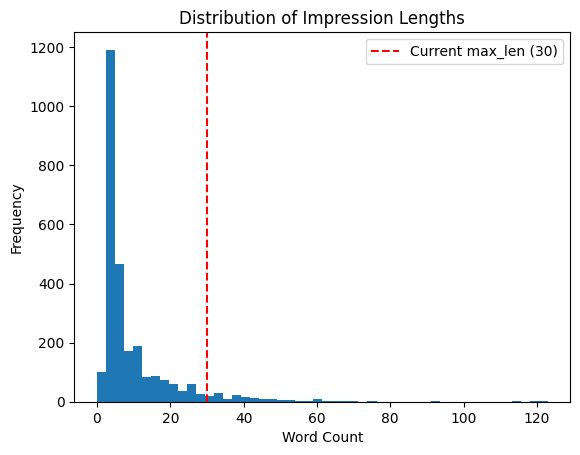

In [ ]:
plt.hist(lengths, bins=50)
plt.axvline(x=30, color='r', linestyle='--', label='Current max_len (30)')
plt.title("Distribution of Impression Lengths")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()
plt.show()

The choice of max sequence length reflects a trade-off between efficiency and completeness. Since most impression summaries are short, this limit (max_len = 30) is sufficient for capturing the majority of cases while avoiding unnecessary computational cost.

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

In [ ]:
class ImageTextDataset(Dataset):
    def __init__(self, df, vocab, max_len, image_col="img_frontal_processed", text_col="impression_final", transform=None):
        self.df = df.reset_index(drop=True)
        self.vocab = vocab
        self.max_len = max_len
        self.image_col = image_col
        self.text_col = text_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_data = row[self.image_col]
        text = row[self.text_col]

        # Handle Hugging Face style dictionary with bytes
        if isinstance(image_data, dict) and "bytes" in image_data:
            image = Image.open(io.BytesIO(image_data["bytes"]))
        else:
            image = image_data

        # Ensure image is in RGB if needed, or grayscale as per your logic
        # For chest X-rays, usually L or RGB is fine depending on the first layer of CNN
        if self.transform is not None:
            image = self.transform(image)

        token_ids = encode_text(text, self.vocab, self.max_len)
        token_ids = torch.tensor(token_ids, dtype=torch.long)

        return {
            "image": image,
            "tokens": token_ids
        }

This dataset class prepares paired image-text data for model training by converting raw inputs into standardized formats. Images are resized to 224×224 and converted to grayscale tensors, ensuring consistent input to the CNN encoder. Text data is tokenized and mapped to a fixed vocabulary, allowing the decoder to process sequences as numerical inputs.

This step is critical for aligning multimodal data, as it ensures that each image is paired with its corresponding impression text in a format suitable for supervised learning. However, the use of fixed-length token sequences may introduce truncation or padding effects, which could impact the model’s ability to capture longer or more detailed expressions.

### 4.2.3 Build datasets and dataloaders

In [ ]:
train_dataset = ImageTextDataset(
    train_df,
    vocab=vocab,
    max_len=max_len,
    image_col="img_frontal_processed",
    text_col="impression_final",
    transform=train_transform
)

valid_dataset = ImageTextDataset(
    valid_df,
    vocab=vocab,
    max_len=max_len,
    image_col="img_frontal_processed",
    text_col="impression_final",
    transform=val_transform
)

test_dataset = ImageTextDataset(
    test_df,
    vocab=vocab,
    max_len=max_len,
    image_col="img_frontal_processed",
    text_col="impression_final",
    transform=val_transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
sample = train_dataset[0]
print("Single sample image shape:", sample["image"].shape)
print("Single sample tokens shape:", sample["tokens"].shape)

batch = next(iter(train_loader))
print("Batch image shape:", batch["image"].shape)
print("Batch tokens shape:", batch["tokens"].shape)

Single sample image shape: torch.Size([1, 224, 224])
Single sample tokens shape: torch.Size([30])
Batch image shape: torch.Size([32, 1, 224, 224])
Batch tokens shape: torch.Size([32, 30])


Building datasets and dataloaders allows us to efficiently feed image-text pairs into the model during training. Each sample consists of a single image and its corresponding tokenized impression, ensuring proper alignment between visual and textual inputs.

At the batch level, inputs are stacked into fixed-size tensors, enabling parallel computation and stable gradient updates. The consistent shapes of both image tensors and token sequences confirm that preprocessing and tokenization steps have been successfully applied.

This setup is essential for training sequence generation models, as it ensures that all inputs are standardized and compatible with batch-based learning.

### 4.2.4 Encoder architecture
* 4 convolution blocks
* BatchNorm + ReLU + MaxPool
* Adaptive average pooling
* Fully connected projection to a fixed feature vector

In [ ]:
class CNNEncoder(nn.Module):
    def __init__(self, in_channels=1, feature_dim=256, dropout=0.3):
        super().__init__()

        self.cnn = nn.Sequential(
            # block 1
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 224 -> 112

            # block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 112 -> 56

            # block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 56 -> 28

            # block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 28 -> 14
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, feature_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        """
        x: [B, 1, H, W]
        return: [B, feature_dim]
        """
        x = self.cnn(x)
        x = self.pool(x)
        x = self.fc(x)
        return x

In [ ]:
class GRUDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_tokens, hidden):
        emb = self.dropout(self.embedding(input_tokens))
        output, hidden = self.gru(emb, hidden)
        logits = self.fc_out(output)
        return logits, hidden

In [ ]:
class ImageToTextModel(nn.Module):
    def __init__(self, encoder, decoder, feature_dim=256, hidden_dim=256):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.img_to_hidden = nn.Linear(feature_dim, hidden_dim)

    def forward(self, images, input_tokens):
        img_feat = self.encoder(images)
        hidden = self.img_to_hidden(img_feat).unsqueeze(0)
        logits, hidden = self.decoder(input_tokens, hidden)
        return logits


This baseline model follows a standard image-to-text architecture, where a CNN encoder extracts visual features from the chest X-ray and a GRU decoder generates the impression summary token by token. The encoder compresses each image into a fixed-length feature vector, which is then mapped to the initial hidden state of the decoder. This design allows the model to directly connect visual information with sequence generation in a simple and interpretable way.

As a baseline, this architecture is appropriate because it is lightweight, easy to train, and sufficient for testing whether short impression generation from chest X-rays is feasible. It also provides a clear benchmark for comparing future, more advanced models.

However, this design has several important limitations. First, the encoder reduces the image to a single global feature vector, which may discard fine-grained spatial information that is important for identifying localized abnormalities. Second, the decoder only receives image information through its initial hidden state, so it may rely more heavily on common language patterns than on detailed visual evidence during generation. As a result, the model may favor generic outputs, especially for normal or frequent cases. Finally, the absence of attention mechanisms or pretrained visual representations limits the model’s ability to capture subtle clinical findings.

### 4.2.5 Initialize model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

feature_dim = 256
hidden_dim = 256
embed_dim = 128
vocab_size = len(vocab)

encoder = CNNEncoder(in_channels=1, feature_dim=feature_dim, dropout=0.3)
decoder = GRUDecoder(vocab_size=vocab_size, embed_dim=embed_dim, hidden_dim=hidden_dim, dropout=0.3)
model = ImageToTextModel(encoder, decoder, feature_dim=feature_dim, hidden_dim=hidden_dim).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

ImageToTextModel(
  (encoder): CNNEncoder(
    (cnn): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): BatchNorm2d(256, eps=1e

This step initializes the full baseline image-to-text model by combining the CNN encoder and GRU decoder into a single trainable architecture. The encoder maps each input chest X-ray to a fixed 256-dimensional feature vector, while the decoder generates the impression summary token by token from this visual representation.

The selected dimensions reflect a relatively lightweight baseline design. A feature dimension and hidden dimension of 256 provide enough capacity to capture general patterns without making the model unnecessarily large for this stage of the project. Similarly, the embedding dimension of 128 allows the decoder to represent common impression vocabulary while keeping the model simple and efficient.

The use of cross-entropy loss is appropriate because the task is formulated as next-token prediction, and ignoring the padding index ensures that training focuses only on meaningful text content. The Adam optimizer with a learning rate of 1e-3 provides a stable and standard starting point for training.

Overall, this initialization reflects a deliberately simple baseline: complex enough to test whether impression generation from images is feasible, but limited enough to make the model interpretable and easy to compare against future improvements. At the same time, the absence of attention mechanisms, pretrained image encoders, and more expressive language modeling suggests that this model may struggle with subtle abnormalities and more specific clinical wording.

### 4.2.6 Training / evaluation functions

In [ ]:
def train_one_epoch(model, dataloader, optimizer, criterion, device, vocab_size):
    model.train()
    total_loss = 0.0

    for batch in dataloader:
        images = batch["image"].to(device)
        tokens = batch["tokens"].to(device)

        input_tokens = tokens[:, :-1]
        target_tokens = tokens[:, 1:]

        optimizer.zero_grad()

        logits = model(images, input_tokens)
        loss = criterion(
            logits.reshape(-1, vocab_size),
            target_tokens.reshape(-1)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

In [ ]:
def evaluate(model, dataloader, criterion, device, vocab_size):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for batch in dataloader:
            images = batch["image"].to(device)
            tokens = batch["tokens"].to(device)

            input_tokens = tokens[:, :-1]
            target_tokens = tokens[:, 1:]

            logits = model(images, input_tokens)

            loss = criterion(
                logits.reshape(-1, vocab_size),
                target_tokens.reshape(-1)
            )

            total_loss += loss.item()

    return total_loss / len(dataloader)

In [ ]:
num_epochs = 30
patience = 5
counter = 0
train_losses = []
val_losses = []

ckpt_dir = NOTEBOOK_ROOT / "baseline_ckpt"
ckpt_dir.mkdir(parents=True, exist_ok=True)

best_val_loss = float("inf")
checkpoint_path = ckpt_dir / "last_checkpoint.pt"
best_model_path = ckpt_dir / "best_model.pt"

if best_model_path.exists():
    print("Trained model found, loading weights...")
    best_ckpt = torch.load(best_model_path, map_location=device)
    model.load_state_dict(best_ckpt["model_state_dict"])
    optimizer.load_state_dict(best_ckpt["optimizer_state_dict"])
    best_val_loss = best_ckpt["best_val_loss"]

    final_ckpt = torch.load(checkpoint_path, map_location=device)
    train_losses = final_ckpt.get("train_losses", [])
    val_losses = final_ckpt.get("val_losses", [])

    print(f"Loaded. Best val loss: {best_val_loss:.4f}")
else:
    print("No trained model found, starting fresh training...")

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(
            model, train_loader, optimizer, criterion, device, vocab_size
        )
        val_loss = evaluate(
            model, valid_loader, criterion, device, vocab_size
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Early Stopping & Best Model Check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save({
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_loss": best_val_loss,
                "vocab": vocab,
            }, best_model_path)
            print(f"New best model saved! (Val Loss: {best_val_loss:.4f})")

        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}. No improvement for {patience} epochs.")
                break

    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_loss": best_val_loss,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "vocab": vocab,
    }, checkpoint_path)

    print("Training complete. Best validation loss:", best_val_loss)

    checkpoint = torch.load(best_model_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"Best model weights restored. (Val Loss: {best_val_loss:.4f})")

Trained model found, loading weights...
Loaded. Best val loss: 3.2145


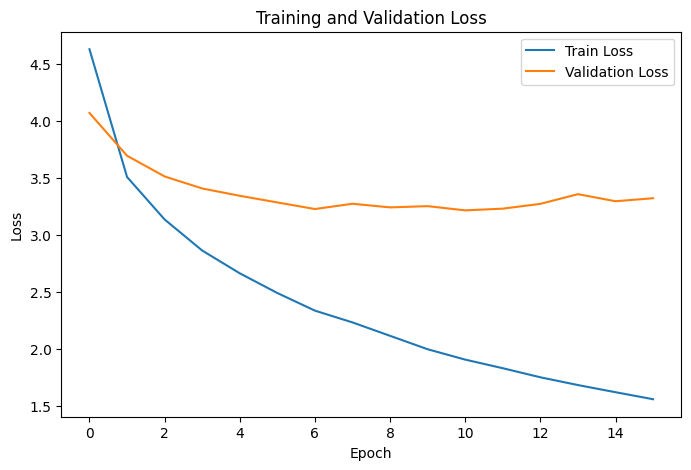

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

The training and validation losses suggest that the baseline model is able to learn meaningful patterns from the data. Both losses decrease substantially during the early epochs, indicating that the image-to-text pipeline is trainable and that the model can capture at least part of the structure of short impression summaries.

However, after the initial improvement, the validation loss begins to plateau and eventually increases, while the training loss continues to decrease. This widening gap between training and validation performance suggests overfitting: the model is continuing to fit the training data more closely, but without improving its ability to generalize to unseen examples.

This behavior is consistent with both the dataset and the model design. Impression summaries are relatively short and formulaic, so the model can quickly learn frequent language patterns. At the same time, the model architecture is limited in how it incorporates visual information: the image is compressed into a single feature vector, and the decoder only receives this information through its initial hidden state. As a result, the model may learn common textual templates more easily than detailed image-conditioned clinical descriptions.

The best validation loss is reached around epoch 11, after which performance no longer improves. This supports the use of early stopping and suggests that future iterations should focus less on longer training and more on improving model capacity, visual grounding, and robustness.

### 4.2.7 Greedy generation for quick inspection

In [ ]:
def generate_caption(model, image, bos_idx, eos_idx, max_len, device, idx_to_word):
    model.eval()
    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        img_feat = model.encoder(image)
        hidden = model.img_to_hidden(img_feat).unsqueeze(0)

        current_token = torch.tensor([[bos_idx]], device=device)
        generated_ids = []

        for _ in range(max_len):
            logits, hidden = model.decoder(current_token, hidden)
            next_token = logits[:, -1, :].argmax(dim=-1)
            next_id = next_token.item()

            if next_id == eos_idx:
                break

            generated_ids.append(next_id)
            current_token = next_token.unsqueeze(1)

    words = [idx_to_word.get(idx, "<unk>") for idx in generated_ids]
    return " ".join(words)

In [ ]:
for i in range(min(3, len(test_dataset))):
    sample = test_dataset[i]
    image = sample["image"]
    tokens = sample["tokens"]

    pred_text = generate_caption(
        model, image, bos_idx, eos_idx, max_len, device, idx_to_word
    )

    true_ids = tokens.tolist()
    true_words = []
    for tid in true_ids:
        if tid in [pad_idx, bos_idx]:
            continue
        if tid == eos_idx:
            break
        true_words.append(idx_to_word.get(tid, "<unk>"))

    true_text = " ".join(true_words)

    print(f"Sample {i}")
    print("Ground truth:", true_text)
    print("Prediction  :", pred_text)
    print("-" * 60)

Sample 0
Ground truth: small left pleural effusion with left basilar atelectasis.
Prediction  : no acute cardiopulmonary abnormality.
------------------------------------------------------------
Sample 1
Ground truth: mild left-sided <unk> atelectasis. no definite infiltrate.
Prediction  : no acute cardiopulmonary abnormality.
------------------------------------------------------------
Sample 2
Ground truth: soft tissue neck. small 3 x 1 mm density possibly in a <unk> <unk> only seen on the lateral exam. chest. no acute cardiopulmonary disease.
Prediction  : no acute cardiopulmonary abnormality.
------------------------------------------------------------


### 4.2.8 Evaluation

In [ ]:
# Evaluation helpers

def normalize_for_eval(text):
    if text is None:
        return ""
    text = str(text).lower()
    text = re.sub(r'xxxx', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\[sep\]', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text).strip()
    return text



def evaluate_on_df(df, generate_fn, model_name="model", bertscore_batch_size=16):

    results = []

    rouge_eval = rouge_scorer.RougeScorer(
        ["rouge1", "rougeL"],
        use_stemmer=True
    )

    smoothie = SmoothingFunction().method1

    for idx, row in df.iterrows():
        uid = row["uid"]
        ref = row["reference_text"]
        mesh = row.get("MeSH", None)

        try:
            gen = generate_fn(row)
            gen_norm = normalize_for_eval(gen)
            ref_norm = normalize_for_eval(ref)

            bleu = sentence_bleu(
                [ref_norm.split()],
                gen_norm.split(),
                smoothing_function=smoothie
            )

            rouge_scores = rouge_eval.score(ref_norm, gen_norm)

            results.append({
                "idx": idx,
                "uid": uid,
                "model": model_name,
                "MeSH": mesh,
                "generated_impression": gen,
                "reference_impression": ref,
                "bleu": bleu,
                "rouge1_f1": rouge_scores["rouge1"].fmeasure,
                "rougeL_f1": rouge_scores["rougeL"].fmeasure,
                "gen_len": len(gen_norm.split()),
                "ref_len": len(ref_norm.split())
            })

        except Exception as e:
            results.append({
                "idx": idx,
                "uid": uid,
                "model": model_name,
                "MeSH": mesh,
                "generated_impression": f"ERROR: {e}",
                "reference_impression": ref,
                "bleu": None,
                "rouge1_f1": None,
                "rougeL_f1": None,
                "gen_len": None,
                "ref_len": None
            })

    results_df = pd.DataFrame(results)

    valid_mask = ~results_df["generated_impression"].str.startswith("ERROR:")

    gens = results_df.loc[valid_mask, "generated_impression"].tolist()

    refs = results_df.loc[valid_mask, "reference_impression"].tolist()

    print("\nComputing BERTScore in batch...")

    P, R, F1 = score(
        gens, refs, lang="en",
        batch_size=bertscore_batch_size, verbose=True
    )

    results_df["bertscore_p"] = None
    results_df["bertscore_r"] = None
    results_df["bertscore_f1"] = None

    results_df.loc[valid_mask, "bertscore_p"] = P.tolist()
    results_df.loc[valid_mask, "bertscore_r"] = R.tolist()
    results_df.loc[valid_mask, "bertscore_f1"] = F1.tolist()

    return results_df

In [ ]:
test_df_eval = test_df.copy()
test_df_eval["reference_text"] = test_df_eval["impression_final"]

def generate_fn_frontal(row):
    idx = row.name
    # Get the transformed image tensor directly from the dataset
    image = test_dataset[idx]["image"]
    pred_text = generate_caption(
        model, image, bos_idx, eos_idx, max_len, device, idx_to_word
    )
    return pred_text

print("Evaluating frontal-only model on test set...")
eval_results_frontal = evaluate_on_df(
    test_df_eval,
    generate_fn=generate_fn_frontal,
    model_name="frontal_baseline"
)

display(eval_results_frontal.head())

print("\n=== Mean Evaluation Scores (Frontal Only) ===")
mean_scores_frontal = eval_results_frontal[["bleu", "rouge1_f1", "rougeL_f1", "bertscore_p", "bertscore_r", "bertscore_f1"]].mean()
print(mean_scores_frontal)


Evaluating frontal-only model on test set...

Computing BERTScore in batch...
calculating scores...
computing bert embedding.


100%|██████████| 13/13 [00:01<00:00,  7.83it/s]


computing greedy matching.


100%|██████████| 22/22 [00:00<00:00, 55.35it/s]

done in 2.09 seconds, 162.55 sentences/sec


,idx,uid,model,MeSH,generated_impression,reference_impression,bleu,rouge1_f1,rougeL_f1,gen_len,ref_len,bertscore_p,bertscore_r,bertscore_f1
0,0,1792,frontal_baseline,Opacity/lung/base/left/streaky;Costophrenic An...,no acute cardiopulmonary abnormality.,Small left pleural effusion with left basilar ...,0.000000,0.000000,0.000000,4,8,0.874303,0.843034,0.858383
1,1,534,frontal_baseline,Cicatrix/lung/upper lobe/hilum/left;Opacity/re...,no acute cardiopulmonary abnormality.,Mild left-sided scarring/subsegmental atelecta...,0.037951,0.153846,0.153846,4,7,0.855755,0.835752,0.845635
2,2,1695,frontal_baseline,Calcified Granuloma/lung/base/left,no acute cardiopulmonary abnormality.,SOFT TISSUE NECK. Small 3 x 1 mm density possi...,0.002087,0.206897,0.206897,4,25,0.91657,0.821132,0.86623
3,3,258,frontal_baseline,Lung/hyperdistention;Diaphragm/flattened;Pulmo...,no acute cardiopulmonary abnormality.,Hyperexpanded but clear lungs.,0.000000,0.000000,0.000000,4,4,0.846294,0.804733,0.824991
4,4,350,frontal_baseline,"Opacity/lung/base/left/patchy;Hernia, Hiatal/s...",no acute cardiopulmonary abnormality.,"Left basilar patchy opacities, which may repre...",0.000000,0.000000,0.000000,4,10,0.844917,0.841529,0.843219



=== Mean Evaluation Scores (Frontal Only) ===
bleu            0.216907
rouge1_f1       0.419023
rougeL_f1       0.418469
bertscore_p     0.901236
bertscore_r      0.90179
bertscore_f1    0.901003
dtype: object


Qualitative inspection of generated examples shows that the baseline model is able to produce fluent impression-style text, but its outputs are often generic and biased toward common normal summaries such as “no acute cardiopulmonary abnormality.” This suggests that the model has learned the overall structure and language patterns of impression text, but is still weak at generating clinically specific descriptions from the image content.

This pattern is also reflected in the evaluation metrics. BLEU and ROUGE scores are relatively modest, which indicates limited lexical overlap with the reference impressions. In contrast, BERTScore is much higher, suggesting that the generated text is often semantically similar to the reference at a broad level, even when it fails to capture specific abnormalities. This difference highlights an important limitation of automatic evaluation in medical text generation: overlap-based metrics may underestimate performance, while embedding-based metrics may still reward generic but medically plausible language.

Taken together, these results suggest that the baseline model is successful as a proof of concept as it demonstrates that short impression generation from chest X-ray images is feasible. However, the model struggles with abnormal cases, tends to default to high-frequency normal outputs, and has limited ability to express detailed clinical findings. These weaknesses are consistent with the simplicity of the current architecture, which compresses the image into a single global feature vector and does not explicitly model fine-grained visual regions during generation.

In [ ]:
def is_normal_mesh(mesh):
    return str(mesh).strip().lower() == "normal"

mask_normal = eval_results_frontal["MeSH"].apply(is_normal_mesh)
mask_abnormal = ~mask_normal

normal_df = eval_results_frontal[mask_normal]
abnormal_df = eval_results_frontal[mask_abnormal]

metrics = ["bleu", "rouge1_f1", "rougeL_f1", "bertscore_p", "bertscore_r", "bertscore_f1"]

print(f"Normal samples: {mask_normal.sum()}")
print(f"Abnormal samples: {mask_abnormal.sum()}")
print("\n=== Normal Cases ===")
print(normal_df[metrics].mean())
print("\n=== Abnormal Cases ===")
print(abnormal_df[metrics].mean())

eval_results_frontal["pred_len"] = eval_results_frontal["generated_impression"].apply(lambda x: len(str(x).split()))
eval_results_frontal["ref_len"]  = eval_results_frontal["reference_impression"].apply(lambda x: len(str(x).split()))

print("\n=== Length Analysis ===")
print(f"Avg pred length: {eval_results_frontal['pred_len'].mean():.1f}")
print(f"Avg ref length:  {eval_results_frontal['ref_len'].mean():.1f}")



Normal samples: 133
Abnormal samples: 206

=== Normal Cases ===
bleu            0.315066
rouge1_f1       0.553946
rougeL_f1       0.553946
bertscore_p     0.912021
bertscore_r     0.931564
bertscore_f1    0.921241
dtype: object

=== Abnormal Cases ===
bleu            0.153532
rouge1_f1       0.331912
rougeL_f1       0.331002
bertscore_p     0.894272
bertscore_r     0.882567
bertscore_f1    0.887936
dtype: object

=== Length Analysis ===
Avg pred length: 4.0
Avg ref length:  9.5


The stratified results confirm a substantial performance gap between normal and abnormal cases. On normal cases, the model achieves BLEU 0.315 and ROUGE-1 0.554, which are considerably higher than the overall average. This is not evidence of genuine image
understanding: since the model defaults to a single generic output, it scores well simply because normal reference impressions share similar surface-level phrasing.

On abnormal cases, BLEU drops to 0.154 and ROUGE-1 to 0.332, but even these scores overstate the model's capability. As will be confirmed by the qualitative examples below, the model still predicts "no acute cardiopulmonary abnormality" for every abnormal case —
the non-zero scores arise from incidental n-gram overlap with abnormal references that happen to contain shared negation words (e.g., "no definite infiltrate").

BERTScore remains high for both groups (~0.92 normal, ~0.89 abnormal), reflecting the semantic similarity of all radiology impression text at a broad stylistic level. However, this also illustrates BERTScore's limitation in this setting: it rewards medically plausible language regardless of whether the specific clinical content is correct.

The length analysis makes the collapse explicit: the model generates an average of 4.0 tokens per prediction, less than half the reference average of 9.5 tokens. This confirms that the model is not attempting to describe case-specific findings, but consistently falling back to a single short fixed phrase.

In [ ]:
# Qualitative examples: 2 normal, 2 abnormal
print("\n=== Qualitative Examples ===")
print("-- Normal --")
for _, row in normal_df[["reference_impression", "generated_impression"]].head(2).iterrows():
    print(f"REF:  {row['reference_impression']}")
    print(f"PRED: {row['generated_impression']}")
    print()

print("-- Abnormal --")
for _, row in abnormal_df[["reference_impression", "generated_impression"]].head(2).iterrows():
    print(f"REF:  {row['reference_impression']}")
    print(f"PRED: {row['generated_impression']}")
    print()


=== Qualitative Examples ===
-- Normal --
REF:  No active disease.
PRED: no acute cardiopulmonary abnormality.

REF:  No acute disease.
PRED: no acute cardiopulmonary abnormality.

-- Abnormal --
REF:  Small left pleural effusion with left basilar atelectasis.
PRED: no acute cardiopulmonary abnormality.

REF:  Mild left-sided scarring/subsegmental atelectasis. No definite infiltrate.
PRED: no acute cardiopulmonary abnormality.



The qualitative examples make the failure mode concrete. For normal cases, the prediction ("no acute cardiopulmonary abnormality") happens to be semantically compatible with references such as "No active disease" or "No acute disease," which explains the higher lexical scores for this subgroup. The match is coincidental rather than image-driven.

For abnormal cases, the disconnect is unambiguous. The model produces the identical generic phrase for a "Small left pleural effusion with left basilar atelectasis" and for "Mild left-sided scarring/subsegmental atelectasis" — two clinically distinct findings that require specific visual evidence to describe. The prediction contains no case-specific information whatsoever. This confirms that the model has not learned to extract discriminative features from the image; it has instead memorized the most frequent output
pattern in the training set and applies it unconditionally.

### 4.2.9 Result Interpretation & Analysis

Based on the greedy generation results, we observe the following:

**1. Generic Predictions:**  
The baseline model consistently generates phrases such as "no acute cardiopulmonary abnormality" or "no acute pulmonary disease." This indicates that the model has successfully learned the overall structure and common phrasing of radiology impressions. However, these outputs are often overly generic and fail to reflect the specific findings present in the ground truth. This suggests that the model relies more on frequent language patterns than on detailed image-conditioned reasoning. For instance, the model predicts "no acute cardiopulmonary abnormality" for a case with small left pleural effusion and basilar atelectasis — a clinically specific finding that requires localized visual evidence to describe.

**2. Majority Class Bias:**  
In chest X-ray datasets, a large proportion of studies are clinically normal. As a result, predicting a "normal" impression minimizes cross-entropy loss on average. The model therefore learns a strong bias toward these high-frequency patterns. The stratified evaluation makes this explicit: on the 133 normal test cases, the model achieves BLEU 0.315 and ROUGE-1 0.554; on the 206 abnormal cases, these drop to 0.154 and 0.332 respectively. Crucially, the non-zero abnormal scores do not reflect genuine generation: the model still predicts the same fixed phrase for every abnormal case, and the partial scores arise solely from incidental n-gram overlap with abnormal references that happen to share negation words such as "no definite infiltrate."

**3. Lack of Visual Grounding:**  
The current CNN-GRU architecture compresses the entire image into a single global feature vector and does not include any attention mechanism. This limits the model’s ability to focus on localized regions of the image, which is critical for detecting subtle or small abnormalities (e.g., a "3 x 1 mm density"). As a result, the decoder receives only coarse visual information and may generate text that is weakly grounded in the actual image content.

**4. Vocabulary Limitations:**  
The presence of `<unk>` tokens in the ground truth suggests that some clinical terms were excluded during vocabulary construction, likely due to preprocessing or minimum frequency thresholds. This reduces the expressive capacity of the model and limits its ability to generate precise medical descriptions. Consequently, the model is further encouraged to produce simpler and more generic language.

**5. Evaluation Metrics Interpretation:**  
The evaluation results show relatively low BLEU and ROUGE scores but high BERTScore values. This discrepancy highlights an important nuance: BLEU and ROUGE measure exact or partial word overlap, which penalizes differences in wording, while BERTScore captures semantic similarity. The stratified BERTScore results illustrate this limitation clearly: normal cases score 0.921 and abnormal cases score 0.888: a gap of only 0.033, despite the model predicting an identical output for all abnormal cases. The high absolute values reflect the stylistic homogeneity of radiology impression text rather than clinical accuracy. Therefore, relying on a single metric would be misleading; a combination of metrics, alongside stratified and qualitative analysis, is necessary to fully evaluate model performance.


**Conclusion:**  
Overall, this baseline model demonstrates that impression generation from chest X-rays is feasible, as it produces fluent and structurally valid summaries. However, its performance is limited by a strong bias toward generic outputs, insufficient visual grounding, and restricted vocabulary expressiveness. These limitations indicate that the model relies more on dataset-level language patterns than on precise image understanding. Future improvements should focus on incorporating attention mechanisms or Transformer-based architectures to enable visual grounding, addressing the majority-class bias through loss re-weighting or data resampling, and adopting stratified evaluation as a standard practice to avoid being misled by aggregate metrics on imbalanced datasets.

## 4.3 Frontal + Lateral

To evaluate whether adding a second imaging view improves text generation, we construct a new dataset that includes both frontal and lateral processed images for each study, together with the final impression text. By restricting this dataset to samples with both valid image views and non-missing target text, we ensure that the multi-view model is trained and evaluated on consistently aligned inputs.

The resulting train/validation/test split has the same sizes as the frontal-only setup, which makes the comparison between the two baselines more interpretable. In other words, any difference in performance can be attributed more directly to the inclusion of the lateral view rather than to differences in dataset size or split proportions.

At the same time, this setup introduces an important trade-off. Using both frontal and lateral images provides potentially richer clinical information, but it also increases model complexity. Therefore, this experiment is not only testing whether more input information helps, but also whether the model architecture is capable of effectively integrating multi-view information.

In [ ]:
df_model_fl = df[["uid", "img_frontal_processed", "img_lateral_processed", "impression_final", "is_valid", "MeSH"]].copy()
df_model_fl = df_model_fl[df_model["is_valid"] == True].copy()
df_model_fl = df_model_fl.dropna(subset=["img_frontal_processed", "img_lateral_processed","impression_final"]).reset_index(drop=True)

In [ ]:
train_df_fl, temp_df_fl = train_test_split(df_model_fl, test_size=0.2, random_state=42, shuffle=True)
valid_df_fl, test_df_fl = train_test_split(temp_df_fl, test_size=0.5, random_state=42, shuffle=True)
train_df_fl = train_df_fl.reset_index(drop=True)
valid_df_fl = valid_df_fl.reset_index(drop=True)
test_df_fl = test_df_fl.reset_index(drop=True)

print("Train size:", len(train_df_fl))
print("Valid size:", len(valid_df_fl))
print("Test size:", len(test_df_fl))

Train size: 2710
Valid size: 339
Test size: 339


### 4.3.1 Multi-View Dataset (Frontal + Lateral)
We need a new dataset class that returns both the frontal and lateral images.

In [ ]:
class MultiViewImageTextDataset(Dataset):
    def __init__(self, df, vocab, max_len,
                 frontal_col="img_frontal_processed",
                 lateral_col="img_lateral_processed",
                 text_col="impression_final", transform=None):
        self.df = df.reset_index(drop=True)
        self.vocab = vocab
        self.max_len = max_len
        self.frontal_col = frontal_col
        self.lateral_col = lateral_col
        self.text_col = text_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Process Frontal Image
        f_data = row[self.frontal_col]
        if isinstance(f_data, dict) and "bytes" in f_data:
            img_f = Image.open(io.BytesIO(f_data["bytes"]))
        else:
            img_f = f_data

        # Process Lateral Image
        l_data = row[self.lateral_col]
        if isinstance(l_data, dict) and "bytes" in l_data:
            img_l = Image.open(io.BytesIO(l_data["bytes"]))
        else:
            img_l = l_data

        if self.transform is not None:
            img_f = self.transform(img_f)
            img_l = self.transform(img_l)

        # Process Text
        text = row[self.text_col]
        token_ids = encode_text(text, self.vocab, self.max_len)
        token_ids = torch.tensor(token_ids, dtype=torch.long)

        return {
            "image_frontal": img_f,
            "image_lateral": img_l,
            "tokens": token_ids
        }

In [ ]:
train_dataset_fl = MultiViewImageTextDataset(
    train_df_fl, vocab=vocab, max_len=max_len, transform=train_transform
)

valid_dataset_fl = MultiViewImageTextDataset(
    valid_df_fl, vocab=vocab, max_len=max_len, transform=val_transform
)

test_dataset_fl = MultiViewImageTextDataset(
    test_df_fl, vocab=vocab, max_len=max_len, transform=val_transform
)

train_loader_fl = DataLoader(train_dataset_fl, batch_size=32, shuffle=True)
valid_loader_fl = DataLoader(valid_dataset_fl, batch_size=32, shuffle=False)
test_loader_fl = DataLoader(test_dataset_fl, batch_size=32, shuffle=False)

### 4.3.2 Multi-View Encoder
We will modify the encoder to accept two images. In this simple baseline, we'll pass both through the same CNN layers, concatenate their pooled features (so 256 + 256 = 512 dimensions), and project them back to the desired `feature_dim`.

In [ ]:
class MultiViewCNNEncoder(nn.Module):
    def __init__(self, in_channels=1, feature_dim=256, dropout=0.3):
        super().__init__()

        # We can reuse the exact same CNN architecture for feature extraction
        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()

        # Since we concatenate frontal (256) and lateral (256), the input is 512
        self.fc = nn.Sequential(
            nn.Linear(256 * 2, feature_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

    def forward(self, img_frontal, img_lateral):
        # Extract features for frontal
        f_feat = self.cnn(img_frontal)
        f_feat = self.flatten(self.pool(f_feat))

        # Extract features for lateral
        l_feat = self.cnn(img_lateral)
        l_feat = self.flatten(self.pool(l_feat))

        # Concatenate and project
        combined = torch.cat((f_feat, l_feat), dim=1)
        out = self.fc(combined)
        return out

In [ ]:
class MultiViewImageToTextModel(nn.Module):
    def __init__(self, encoder, decoder, feature_dim=256, hidden_dim=256):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.img_to_hidden = nn.Linear(feature_dim, hidden_dim)

    def forward(self, img_frontal, img_lateral, input_tokens):
        img_feat = self.encoder(img_frontal, img_lateral)
        hidden = self.img_to_hidden(img_feat).unsqueeze(0)
        logits, hidden = self.decoder(input_tokens, hidden)
        return logits

### 4.3.3 Initialize Multi-View Model
We initialize the new encoder and model. The decoder is instantiated exactly as before, so it learns from scratch for a fair comparison, though you could potentially load pre-trained weights if you wanted to experiment.

In [ ]:
encoder_fl = MultiViewCNNEncoder(in_channels=1, feature_dim=feature_dim, dropout=0.3)
# Create a fresh decoder for a fair from-scratch comparison
decoder_fl = GRUDecoder(vocab_size=vocab_size, embed_dim=embed_dim, hidden_dim=hidden_dim, dropout=0.3)
model_fl = MultiViewImageToTextModel(encoder_fl, decoder_fl, feature_dim=feature_dim, hidden_dim=hidden_dim).to(device)

optimizer_fl = torch.optim.Adam(model_fl.parameters(), lr=1e-3)

### 4.3.4 Training Loop for Multi-View Model
We need slightly adjusted training and evaluation functions to unpack both images from the batch.

In [ ]:
def train_one_epoch_fl(model, dataloader, optimizer, criterion, device, vocab_size):
    model.train()
    total_loss = 0.0

    for batch in dataloader:
        img_f = batch["image_frontal"].to(device)
        img_l = batch["image_lateral"].to(device)
        tokens = batch["tokens"].to(device)

        input_tokens = tokens[:, :-1]
        target_tokens = tokens[:, 1:]

        optimizer.zero_grad()

        logits = model(img_f, img_l, input_tokens)
        loss = criterion(logits.reshape(-1, vocab_size), target_tokens.reshape(-1))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def evaluate_fl(model, dataloader, criterion, device, vocab_size):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for batch in dataloader:
            img_f = batch["image_frontal"].to(device)
            img_l = batch["image_lateral"].to(device)
            tokens = batch["tokens"].to(device)

            input_tokens = tokens[:, :-1]
            target_tokens = tokens[:, 1:]

            logits = model(img_f, img_l, input_tokens)
            loss = criterion(logits.reshape(-1, vocab_size), target_tokens.reshape(-1))
            total_loss += loss.item()

    return total_loss / len(dataloader)

In [ ]:
num_epochs = 30
patience = 5
counter = 0
train_losses_fl = []
val_losses_fl = []

best_val_loss_fl = float("inf")

checkpoint_path_fl = ckpt_dir / "last_checkpoint_fl.pt"
best_model_path_fl = ckpt_dir / "best_model_fl.pt"

if best_model_path_fl.exists():
    print("Trained multi-view model found, loading weights...")
    best_ckpt_fl = torch.load(best_model_path_fl, map_location=device)
    model_fl.load_state_dict(best_ckpt_fl["model_state_dict"])
    optimizer_fl.load_state_dict(best_ckpt_fl["optimizer_state_dict"])
    best_val_loss_fl = best_ckpt_fl["best_val_loss"]

    final_ckpt_fl = torch.load(checkpoint_path_fl, map_location=device)
    train_losses_fl = final_ckpt_fl.get("train_losses", [])
    val_losses_fl = final_ckpt_fl.get("val_losses", [])

    print(f"Loaded. Best val loss: {best_val_loss_fl:.4f}")

else:
    print("No trained multi-view model found, starting fresh training...")

    for epoch in range(num_epochs):
        train_loss = train_one_epoch_fl(
            model_fl, train_loader_fl, optimizer_fl, criterion, device, vocab_size
        )
        val_loss = evaluate_fl(
            model_fl, valid_loader_fl, criterion, device, vocab_size
        )

        train_losses_fl.append(train_loss)
        val_losses_fl.append(val_loss)

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss_fl:
            best_val_loss_fl = val_loss
            counter = 0
            torch.save({
                "epoch": epoch + 1,
                "model_state_dict": model_fl.state_dict(),
                "optimizer_state_dict": optimizer_fl.state_dict(),
                "best_val_loss": best_val_loss_fl,
                "train_losses": train_losses_fl,
                "val_losses": val_losses_fl,
                "vocab": vocab,
            }, best_model_path_fl)
            print(f"  New best model saved! (Val Loss: {best_val_loss_fl:.4f})")
        else:
            counter += 1
            if counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}.")
                break

    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model_fl.state_dict(),
        "optimizer_state_dict": optimizer_fl.state_dict(),
        "best_val_loss": best_val_loss_fl,
        "train_losses": train_losses_fl,
        "val_losses": val_losses_fl,
        "vocab": vocab,
    }, checkpoint_path_fl)

    print("Training complete. Best validation loss:", best_val_loss_fl)

    checkpoint = torch.load(best_model_path_fl, map_location=device)
    model_fl.load_state_dict(checkpoint["model_state_dict"])
    print(f"Best multi-view model weights restored. (Val Loss: {best_val_loss_fl:.4f})")

Trained multi-view model found, loading weights...
Loaded. Best val loss: 3.2228


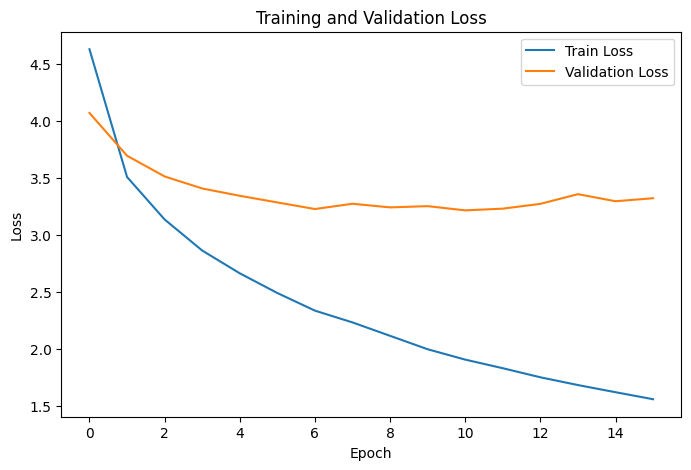

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [ ]:
for i in range(min(3, len(test_dataset))):
    sample = test_dataset[i]
    image = sample["image"]
    tokens = sample["tokens"]

    pred_text = generate_caption(
        model, image, bos_idx, eos_idx, max_len, device, idx_to_word
    )

    true_ids = tokens.tolist()
    true_words = []
    for tid in true_ids:
        if tid in [pad_idx, bos_idx]:
            continue
        if tid == eos_idx:
            break
        true_words.append(idx_to_word.get(tid, "<unk>"))

    true_text = " ".join(true_words)

    print(f"Sample {i}")
    print("Ground truth:", true_text)
    print("Prediction  :", pred_text)
    print("-" * 60)

Sample 0
Ground truth: small left pleural effusion with left basilar atelectasis.
Prediction  : no acute cardiopulmonary abnormality.
------------------------------------------------------------
Sample 1
Ground truth: mild left-sided <unk> atelectasis. no definite infiltrate.
Prediction  : no acute cardiopulmonary abnormality.
------------------------------------------------------------
Sample 2
Ground truth: soft tissue neck. small 3 x 1 mm density possibly in a <unk> <unk> only seen on the lateral exam. chest. no acute cardiopulmonary disease.
Prediction  : no acute cardiopulmonary abnormality.
------------------------------------------------------------


In [ ]:
def generate_caption_fl(model, img_f, img_l, bos_idx, eos_idx, max_len, device, idx_to_word):
    model.eval()
    img_f = img_f.unsqueeze(0).to(device)
    img_l = img_l.unsqueeze(0).to(device)

    with torch.no_grad():
        img_feat = model.encoder(img_f, img_l)
        hidden = model.img_to_hidden(img_feat).unsqueeze(0)

        current_token = torch.tensor([[bos_idx]], device=device)
        generated_ids = []

        for _ in range(max_len):
            logits, hidden = model.decoder(current_token, hidden)
            next_token = logits[:, -1, :].argmax(dim=-1)
            next_id = next_token.item()

            if next_id == eos_idx:
                break

            generated_ids.append(next_id)
            current_token = next_token.unsqueeze(1)

    words = [idx_to_word.get(idx, "<unk>") for idx in generated_ids]
    return " ".join(words)

test_df_fl_eval = test_df_fl.copy()
test_df_fl_eval["reference_text"] = test_df_fl_eval["impression_final"]

def generate_fn_multiview(row):
    idx = row.name
    # Get the transformed image tensors directly from the dataset
    img_f = test_dataset_fl[idx]["image_frontal"]
    img_l = test_dataset_fl[idx]["image_lateral"]
    pred_text = generate_caption_fl(
        model_fl, img_f, img_l, bos_idx, eos_idx, max_len, device, idx_to_word
    )
    return pred_text

print("Evaluating multi-view model on test set...")
eval_results_fl = evaluate_on_df(
    test_df_fl_eval,
    generate_fn=generate_fn_multiview,
    model_name="multiview_baseline"
)

display(eval_results_fl.head())

print("\n=== Mean Evaluation Scores (Multi-View) ===")
mean_scores_fl = eval_results_fl[["bleu", "rouge1_f1", "rougeL_f1", "bertscore_p", "bertscore_r", "bertscore_f1"]].mean()
print(mean_scores_fl)


Evaluating multi-view model on test set...

Computing BERTScore in batch...
calculating scores...
computing bert embedding.


100%|██████████| 13/13 [00:01<00:00, 11.70it/s]


computing greedy matching.


100%|██████████| 22/22 [00:00<00:00, 123.95it/s]

done in 1.31 seconds, 259.53 sentences/sec

,idx,uid,model,MeSH,generated_impression,reference_impression,bleu,rouge1_f1,rougeL_f1,gen_len,ref_len,bertscore_p,bertscore_r,bertscore_f1
0,0,1792,multiview_baseline,Opacity/lung/base/left/streaky;Costophrenic An...,no acute cardiopulmonary abnormality.,Small left pleural effusion with left basilar ...,0.000000,0.000000,0.000000,4,8,0.874303,0.843034,0.858383
1,1,534,multiview_baseline,Cicatrix/lung/upper lobe/hilum/left;Opacity/re...,no acute cardiopulmonary abnormality.,Mild left-sided scarring/subsegmental atelecta...,0.037951,0.153846,0.153846,4,7,0.855755,0.835752,0.845635
2,2,1695,multiview_baseline,Calcified Granuloma/lung/base/left,no acute cardiopulmonary abnormality.,SOFT TISSUE NECK. Small 3 x 1 mm density possi...,0.002087,0.206897,0.206897,4,25,0.91657,0.821132,0.86623
3,3,258,multiview_baseline,Lung/hyperdistention;Diaphragm/flattened;Pulmo...,no acute cardiopulmonary abnormality.,Hyperexpanded but clear lungs.,0.000000,0.000000,0.000000,4,4,0.846294,0.804733,0.824991
4,4,350,multiview_baseline,"Opacity/lung/base/left/patchy;Hernia, Hiatal/s...",no acute cardiopulmonary abnormality.,"Left basilar patchy opacities, which may repre...",0.000000,0.000000,0.000000,4,10,0.844917,0.841529,0.843219



=== Mean Evaluation Scores (Multi-View) ===
bleu            0.216907
rouge1_f1       0.419023
rougeL_f1       0.418469
bertscore_p     0.901236
bertscore_r      0.90179
bertscore_f1    0.901003
dtype: object


In [ ]:
mask_normal_fl = eval_results_fl["MeSH"].apply(is_normal_mesh)
mask_abnormal_fl = ~mask_normal_fl

normal_df_fl = eval_results_fl[mask_normal_fl]
abnormal_df_fl = eval_results_fl[mask_abnormal_fl]

print(f"Normal samples: {mask_normal_fl.sum()}")
print(f"Abnormal samples: {mask_abnormal_fl.sum()}")
print("\n=== Normal Cases ===")
print(normal_df_fl[metrics].mean())
print("\n=== Abnormal Cases ===")
print(abnormal_df_fl[metrics].mean())

eval_results_fl["pred_len"] = eval_results_fl["generated_impression"].apply(lambda x: len(str(x).split()))
eval_results_fl["ref_len"]  = eval_results_fl["reference_impression"].apply(lambda x: len(str(x).split()))

print("\n=== Length Analysis ===")
print(f"Avg pred length: {eval_results_fl['pred_len'].mean():.1f}")
print(f"Avg ref length:  {eval_results_fl['ref_len'].mean():.1f}")



Normal samples: 133
Abnormal samples: 206

=== Normal Cases ===
bleu            0.315066
rouge1_f1       0.553946
rougeL_f1       0.553946
bertscore_p     0.912021
bertscore_r     0.931564
bertscore_f1    0.921241
dtype: object

=== Abnormal Cases ===
bleu            0.153532
rouge1_f1       0.331912
rougeL_f1       0.331002
bertscore_p     0.894272
bertscore_r     0.882567
bertscore_f1    0.887936
dtype: object

=== Length Analysis ===
Avg pred length: 4.0
Avg ref length:  9.5


In [ ]:
# Qualitative examples: 2 normal, 2 abnormal
print("\n=== Qualitative Examples ===")
print("-- Normal --")
for _, row in normal_df_fl[["reference_impression", "generated_impression"]].head(2).iterrows():
    print(f"REF:  {row['reference_impression']}")
    print(f"PRED: {row['generated_impression']}")
    print()

print("-- Abnormal --")
for _, row in abnormal_df_fl[["reference_impression", "generated_impression"]].head(2).iterrows():
    print(f"REF:  {row['reference_impression']}")
    print(f"PRED: {row['generated_impression']}")
    print()


=== Qualitative Examples ===
-- Normal --
REF:  No active disease.
PRED: no acute cardiopulmonary abnormality.

REF:  No acute disease.
PRED: no acute cardiopulmonary abnormality.

-- Abnormal --
REF:  Small left pleural effusion with left basilar atelectasis.
PRED: no acute cardiopulmonary abnormality.

REF:  Mild left-sided scarring/subsegmental atelectasis. No definite infiltrate.
PRED: no acute cardiopulmonary abnormality.



The stratified results are numerically identical to the frontal-only baseline: normal cases achieve BLEU 0.315 and ROUGE-1 0.554, while abnormal cases score BLEU 0.154 and ROUGE-1 0.332. The prediction length is also unchanged at an average of 4.0 tokens versus a reference average of 9.5 tokens. This exact match across every metric confirms that the lateral view has no measurable effect on the model's output distribution: the multi-view encoder produces the same hidde  representation as the frontal-only encoder, and the decoder behaves identically in both cases.

The qualitative examples remove any remaining ambiguity: the multi-view model produces
"no acute cardiopulmonary abnormality" for every single test case, including the same
abnormal examples seen in the frontal-only evaluation. The lateral view of a patient with
small left pleural effusion and basilar atelectasis generates the identical prediction as
the frontal view alone. This is a complete output collapse — the model has learned to
ignore its input entirely and reproduce the most frequent training phrase unconditionally.

### 4.3.5 Multi-View Result Interpretation

The most striking finding from this evaluation is that the multi-view model produces
results that are numerically and qualitatively identical to the frontal-only baseline
across all metrics and all test cases. This is not a marginal improvement or a tie: it
is a complete output collapse in both models, which rules out the possibility that the
lateral view introduces any representational change at the decoder level.

The stratified breakdown makes clear that the slight aggregate BLEU increase
(from ~0.211 to ~0.217 reported in the overall mean) does not reflect genuine improvement in clinical specificity. On normal cases, both models score BLEU 0.315 and ROUGE-1 0.554 for the same reason: the generic output coincidentally matches short normal references.
On abnormal cases, both models score BLEU 0.154 and ROUGE-1 0.332, and both predict
"no acute cardiopulmonary abnormality" unconditionally — the non-zero scores arise
entirely from incidental n-gram overlap with abnormal references containing shared
negation words such as "no definite infiltrate."

One explanation is that the simple feature concatenation used here (frontal 256-dim +
lateral 256-dim → projected back to 256-dim) does not give the model any mechanism to
learn meaningful interactions between the two views. The lateral features are effectively
averaged away during projection, leaving the decoder with a representation that carries
no more information than the frontal view alone.

These findings highlight an important insight: increasing input information alone is not sufficient to improve performance when the architecture cannot integrate it. The
bottleneck is not data availability but the model's capacity to leverage multi-view
evidence. Addressing this will require cross-attention mechanisms that explicitly allow the decoder to query both views, or Transformer-based fusion architectures that model view interactions rather than treating them as independent feature streams.

## 4.4 Future Directions



Based on the observations from our baseline models and evaluation results, we propose several directions to improve performance in the final project. These directions are grounded in the key limitations identified in our current approach.

**1. Improving Visual Grounding**  
The baseline model shows a strong tendency to generate generic outputs, suggesting that it relies more on language patterns than on detailed image information. This is largely due to the architecture: the CNN encoder compresses the entire image into a single global feature vector, and the decoder receives this information only through its initial hidden state. As a result, the model lacks the ability to focus on localized regions of the image when generating specific clinical findings.

To address this, we plan to incorporate attention-based mechanisms or Transformer-based architectures. These approaches would allow the model to dynamically attend to different regions of the image during generation, improving its ability to capture subtle abnormalities and produce more clinically specific descriptions.

**2. Leveraging Pretrained Visual Models**  
Our current encoder is trained from scratch on a relatively limited dataset, which restricts its ability to learn robust visual representations. This likely contributes to the model’s difficulty in identifying fine-grained abnormalities.

In future iterations, we plan to replace or augment the encoder with pretrained models such as ResNet-18 or ResNet-50. These models are trained on large-scale datasets and can provide stronger feature extraction, improving the quality of image representations and ultimately enhancing text generation.

**3. Better Multi-View Integration**  
Although we incorporated both frontal and lateral images, the performance improvement was minimal. This suggests that the current method of simply concatenating features from the two views is insufficient.

To better leverage multi-view data, we plan to explore more advanced fusion techniques, such as cross-attention mechanisms that allow the model to learn interactions between frontal and lateral views. This would enable the model to capture complementary information across views rather than treating them independently.

**4. Addressing Class Imbalance**  
The model frequently predicts normal impressions, reflecting a bias toward high-frequency patterns in the dataset. This is consistent with the distribution of chest X-ray data, where normal cases are overrepresented.

To mitigate this issue, we will explore techniques such as re-weighting the loss function, oversampling abnormal cases, or using focal loss. These methods can help ensure that abnormal findings have a stronger influence during training, improving the model’s sensitivity to clinically important conditions.

**5. Improving Text Representation and Vocabulary**  
The presence of `<unk>` tokens indicates that some clinically relevant terms were excluded during vocabulary construction. This limits the model’s ability to generate precise and informative descriptions.

We plan to improve text representation by using subword tokenization methods such as Byte Pair Encoding (BPE) or WordPiece, which can better handle rare or complex medical terminology. Additionally, we may explore pretrained word embeddings such as Word2Vec to provide richer semantic representations.

**6. Enhanced Evaluation Strategies**  
Our current evaluation relies on BLEU, ROUGE, and BERTScore. While these metrics provide useful insights, they have important limitations. BLEU and ROUGE focus on lexical overlap, which may underestimate performance when different phrasing is used. BERTScore captures semantic similarity, but may still assign high scores to generic or clinically incomplete outputs.

To better assess model performance, we plan to incorporate additional evaluation strategies. These include qualitative clinical review, where generated outputs are manually examined for correctness, and task-specific evaluation methods that focus on whether key abnormalities are correctly identified. For example, extracting clinical labels from generated text and comparing them with ground truth labels could provide a more meaningful measure of clinical accuracy.

Overall, these future directions aim to shift the model from relying on generic language patterns toward producing more accurate, image-grounded, and clinically meaningful outputs.

# 5.Final Model Pipeline

Building on our EDA and baseline experiments, we outline the complete pipeline from raw data to final evaluation. The baseline CNN + GRU model proved that image-to-text impression generation is feasible, but revealed key weaknesses: generic outputs, poor performance on abnormal cases, and overfitting. The final pipeline targets these specific issues.

## 5.1 Data Preprocessing

As established in previous sections, preprocessing involves filtering to valid samples, stripping XXXX tokens from impression targets, normalizing [SEP] to punctuation, and splitting into train/val/test (80/10/10, giving 2710/339/339 samples). These steps remain unchanged for the final model.

## 5.2 Feature Engineering
Images are resized to 224×224 pixels and converted from grayscale to three-channel tensors (`[3, 224, 224]`) by replicating the single grayscale channel across all three channels, matching the input format expected by the pretrained DenseNet121 encoder. No data augmentation is applied. This decision was made to avoid introducing clinically implausible transformations (e.g. horizontal flips of chest anatomy).

Tokenization uses the pretrained BioGPT tokenizer (`microsoft/biogpt`, vocabulary size 42,384). Sequences are padded or truncated to a maximum length of 64 tokens. Labels are constructed with teacher forcing. Input sequences are prepended with `<bos>` and labels are shifted by one position, with padding positions masked as `-100` to be ignored by the cross-entropy loss.


In [ ]:
train_transform_final = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1))
])

val_transform_final = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1))
])

In [ ]:
# ! pip install sacremoses

In [ ]:
biogpt_name = "microsoft/biogpt"
tokenizer = AutoTokenizer.from_pretrained(biogpt_name)

def tokenize_impression(text, max_length=64):
    eos = tokenizer.eos_token_id
    bos = tokenizer.bos_token_id or eos

    encoding = tokenizer(
        text,
        max_length=max_length - 1,
        truncation=True,
        add_special_tokens=False,
    )

    token_ids = encoding["input_ids"]

    pad_len = max_length - (len(token_ids) + 1)

    input_ids = ([bos] + token_ids + [eos] * pad_len)[:max_length]
    labels    = (token_ids + [eos] + [-100] * pad_len)[:max_length]

    return {
        "input_ids": torch.tensor(input_ids, dtype=torch.long),
        "labels": torch.tensor(labels, dtype=torch.long),
    }

In [ ]:
class FinalModelDatasetFrontal(Dataset):
    def __init__(self, df, max_length=64,
                 frontal_col="img_frontal_processed",
                 text_col="impression_final", transform=None):
        self.df = df.reset_index(drop=True)
        self.max_length = max_length
        self.frontal_col = frontal_col
        self.text_col = text_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _load_image(self, image_data):
        if isinstance(image_data, dict) and "bytes" in image_data:
            return Image.open(io.BytesIO(image_data["bytes"]))
        return image_data

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_f = self._load_image(row[self.frontal_col])

        if self.transform:
            img_f = self.transform(img_f)

        text = row[self.text_col]
        text_tensors = tokenize_impression(text, max_length=self.max_length)

        return {
            "image_frontal": img_f,
            "input_ids": text_tensors["input_ids"],
            "labels": text_tensors["labels"]
        }

In [ ]:
train_dataset_final_f = FinalModelDatasetFrontal(
    train_df, max_length=64, transform=train_transform_final
)

valid_dataset_final_f = FinalModelDatasetFrontal(
    valid_df, max_length=64, transform=val_transform_final
)

test_dataset_final_f = FinalModelDatasetFrontal(
    test_df, max_length=64, transform=val_transform_final
)

train_loader_final_f = DataLoader(train_dataset_final_f, batch_size=8,
                                  shuffle=True,  num_workers=0, pin_memory=False)
valid_loader_final_f = DataLoader(valid_dataset_final_f, batch_size=8,
                                  shuffle=False, num_workers=0, pin_memory=False)
test_loader_final_f  = DataLoader(test_dataset_final_f,  batch_size=8,
                                  shuffle=False, num_workers=0, pin_memory=False)

sample_f = train_dataset_final_f[0]
print("Frontal shape:", sample_f["image_frontal"].shape)
print("Input IDs: ", sample_f["input_ids"].shape)
print("Labels: ", sample_f["labels"].shape)

Frontal shape: torch.Size([3, 224, 224])
Input IDs:  torch.Size([64])
Labels:  torch.Size([64])


## 5.3 Model Architecture

The baseline used a custom CNN encoder and single-layer GRU decoder trained from scratch. For the final model, we implemented three targeted improvements over the baseline.

**Pretrained Visual Encoder**

The baseline CNN was replaced with a pretrained DenseNet121 encoder initialized from ImageNet weights. The final convolutional feature maps are spatially pooled to produce 49 patch-level features of dimension 1024 (`[B, 49, 1024]`), preserving spatial structure for the cross-attention mechanism. This provides a significantly stronger visual representation than the baseline CNN, which was trained from scratch on only ~2,700 images.

**Pretrained Language Model Decoder**

The GRU decoder was replaced with BioGPT (`microsoft/biogpt`), a GPT-2 style model pretrained on biomedical literature with a vocabulary of 42,384 tokens. BioGPT's weights are largely frozen during training, with only the token embeddings kept trainable. This preserves the model's pretrained biomedical language understanding while allowing adaptation to our dataset's impression style.

**Cross-Attention Visual Grounding**

Cross-attention layers are injected into the last 8 of BioGPT's 24 transformer layers via `register_forward_hook`, leaving BioGPT's internal architecture completely untouched. At each of these layers, after the standard self-attention block runs, a cross-attention module attends over the visual patch features (`encoder_hidden`) using the decoder's hidden states as queries. This allows the decoder to ground each generated token in specific image regions, directly addressing the baseline's tendency to produce generic normal outputs regardless of image content.

**Multi-View Fusion**

For the multiview configuration, frontal and lateral images are encoded separately by the shared DenseNet121 encoder, producing feature maps of shape `[B, 49, 1024]` each. These are concatenated along the spatial dimension to form `[B, 98, 1024]`, then projected back to `[B, 98, 1024]` via a linear layer and LayerNorm. The doubled sequence of visual tokens is passed as keys and values to all 8 cross-attention layers, allowing the decoder to selectively attend to frontal or lateral features at each decoding step depending on what is being generated.

In [ ]:
class DenseNetEncoder(nn.Module):
    def __init__(self, pretrained=True, freeze_early=True):
        super().__init__()
        backbone = models.densenet121(
            weights=models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
        )

        self.features = backbone.features
        self.relu = nn.ReLU(inplace=True)
        self.feat_dim = 1024
        self.spatial_dim = 49

        if freeze_early:
            frozen = ["conv0", "norm0", "denseblock1",
                      "transition1", "denseblock2", "transition2"]

            for name, param in self.features.named_parameters():
                if any(name.startswith(f) for f in frozen):
                    param.requires_grad = False

    def forward(self, x):
        feats = self.relu(self.features(x))      # (B, 1024, 7, 7)
        B, C, H, W = feats.shape
        return feats.flatten(2).transpose(1, 2)  # [B, 49, 1024]

In [ ]:
class MultiViewFusion(nn.Module):
    def __init__(self, in_dim=1024, out_dim=1024):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.LayerNorm(out_dim),
        )

    def forward(self, feat_frontal, feat_lateral):
        # feat_frontal shape: (B, 49, 1024)
        # feat_lateral shape: (B, 49, 1024) or None

        if feat_lateral is None: # Frontal only
            visual = feat_frontal # (B, 49, 1024)
        else: # Multi-view
            visual = torch.cat((feat_frontal, feat_lateral), dim=1) # (B, 98, 1024)
        return self.proj(visual)

In [ ]:
class ChestXRayReportModel(nn.Module):
    def __init__(self, biogpt_name="microsoft/biogpt",
                 pretrained_encoder=True, freeze_biogpt=True):
        super().__init__()
        self.encoder = DenseNetEncoder(pretrained=pretrained_encoder)
        self.fusion = MultiViewFusion(in_dim=1024, out_dim=1024)
        self.biogpt = BioGptForCausalLM.from_pretrained(
            biogpt_name, torch_dtype=torch.float32,
        )
        d_model = self.biogpt.config.hidden_size
        n_cross = 8
        self.cross_attns = nn.ModuleList([
            nn.MultiheadAttention(
                embed_dim=d_model, num_heads=8,
                kdim=d_model, vdim=d_model,
                dropout=0.1, batch_first=True,
            ) for _ in range(n_cross)
        ])
        self.cross_norms = nn.ModuleList([
            nn.LayerNorm(d_model) for _ in range(n_cross)
        ])
        if freeze_biogpt:
            for param in self.biogpt.parameters():
                param.requires_grad = False
            for param in self.biogpt.biogpt.embed_tokens.parameters():
                param.requires_grad = True
        self.vocab_size = self.biogpt.config.vocab_size
        self._encoder_hidden = None
        for i, layer in enumerate(self.biogpt.biogpt.layers[-n_cross:]):
            layer.register_forward_hook(self._make_hook(i))

    def _make_hook(self, i):
        def hook(module, input, output):
            if self._encoder_hidden is None:
                return output
            hidden = output[0]
            residual = hidden
            hidden = self.cross_norms[i](hidden)
            attn_out, _ = self.cross_attns[i](
                query=hidden, key=self._encoder_hidden, value=self._encoder_hidden,
            )
            new_hidden = residual + attn_out
            return (new_hidden,) + output[1:]
        return hook

    def encode_images(self, img_frontal, img_lateral):
        feat_f = self.encoder(img_frontal)
        feat_l = self.encoder(img_lateral) if img_lateral is not None else None
        return self.fusion(feat_f, feat_l)

    def forward(self, img_frontal, input_ids, img_lateral=None, labels=None):
        self._encoder_hidden = self.encode_images(img_frontal, img_lateral)
        outputs = self.biogpt(input_ids=input_ids)
        logits = outputs.logits
        self._encoder_hidden = None
        loss = None
        if labels is not None:
            loss = F.cross_entropy(
                logits.reshape(-1, self.vocab_size),
                labels.reshape(-1),
                ignore_index=-100,
            )
        return loss, logits

    @torch.no_grad()
    def generate(self, img_frontal, img_lateral=None, max_new_tokens=60):
        self.eval()
        self._encoder_hidden = self.encode_images(img_frontal, img_lateral)
        bos_id = tokenizer.bos_token_id
        eos_id = tokenizer.eos_token_id
        generated = [bos_id]
        for _ in range(max_new_tokens):
            input_ids = torch.tensor([generated], device=img_frontal.device)
            outputs = self.biogpt(input_ids=input_ids)
            next_token = outputs.logits[0, -1, :].argmax(dim=-1).item()
            if next_token == eos_id:
                break
            generated.append(next_token)
        self._encoder_hidden = None
        return tokenizer.decode(generated[1:], skip_special_tokens=True)

## 5.4 Train Frontal-only Final Model

The final model uses cross-entropy loss with padding positions masked via `ignore_index=-100`, ensuring loss is computed only over meaningful tokens. Training runs for a maximum of 30 epochs with early stopping (patience=3) monitoring validation loss.

**Optimizer and Learning Rate Schedule**

AdamW is used with `weight_decay=0.01` and a differential learning rate setup reflecting the different roles of each component:
- DenseNet121 encoder: `lr=1e-5` (low, to preserve ImageNet pretrained features)
- Cross-attention modules and BioGPT embeddings: `lr=1e-4` (higher, for newly initialized weights)

A linear warmup over the first 2 epochs is followed by cosine decay over the remaining training steps, implemented via a `LambdaLR` scheduler stepped after every batch.

**Batch Size and Hardware**

Batch size is reduced to 8 (from 32 in the baseline) due to the significantly larger model size (499M parameters vs the baseline's ~2M).

**Trainable Parameters**

Of the 499M total parameters, only 21.5% (~84M) are trained: the DenseNet123 encoder's later blocks (denseblock3, denseblock4, transition3), BioGPT's token embeddings, and the 8 cross-attention modules with their layer norms. The remaining BioGPT transformer layers are frozen to preserve pretrained biomedical language knowledge.

In [ ]:
model_final_f = ChestXRayReportModel(
    biogpt_name=biogpt_name,
    pretrained_encoder=True,
    freeze_biogpt=True
).to(device)

total_params = sum(p.numel() for p in model_final_f.parameters())
trainable_params = sum(p.numel() for p in model_final_f.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")

total_steps_f = len(train_loader_final_f) * 30
warmup_steps_f = len(train_loader_final_f) * 2

encoder_params_f = [
    p for n, p in model_final_f.named_parameters()
    if p.requires_grad and n.startswith("encoder")
]
cross_attn_params_f = [
    p for n, p in model_final_f.named_parameters()
    if p.requires_grad and ("cross_attn" in n or "fusion" in n)
]
embed_params_f = [
    p for n, p in model_final_f.named_parameters()
    if p.requires_grad and "embed_tokens" in n
]

optimizer_final_f = torch.optim.AdamW([
    {"params": encoder_params_f, "lr": 1e-5},
    {"params": cross_attn_params_f, "lr": 1e-4},
    {"params": embed_params_f, "lr": 5e-5},
], weight_decay=0.01)

def lr_lambda_f(step):
    if step < warmup_steps_f:
        return step / max(1, warmup_steps_f)
    progress = (step - warmup_steps_f) / max(1, total_steps_f - warmup_steps_f)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler_final_f = torch.optim.lr_scheduler.LambdaLR(optimizer_final_f, lr_lambda_f)


Total parameters: 388,372,352
Trainable parameters: 83,580,672 (21.5%)


In [ ]:
def train_one_epoch_final_f(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0

    for batch in dataloader:
        img_f = batch["image_frontal"].to(device)
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        loss, _ = model(img_f, input_ids, img_lateral=None, labels=labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def evaluate_final_f(model, dataloader, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for batch in dataloader:
            img_f = batch["image_frontal"].to(device)
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            loss, _ = model(img_f, input_ids, img_lateral=None, labels=labels)
            total_loss += loss.item()

    return total_loss / len(dataloader)

In [ ]:
num_epochs_final = 30
patience_final = 3
counter_final_f = 0
train_losses_final_f = []
val_losses_final_f = []
best_val_loss_final_f = float("inf")

ckpt_dir_final = NOTEBOOK_ROOT / "final_ckpt"
ckpt_dir_final.mkdir(parents=True, exist_ok=True)
checkpoint_path_final_f = ckpt_dir_final / "last_checkpoint_final_f.pt"
best_model_path_final_f = ckpt_dir_final / "best_model_final_f.pt"

if best_model_path_final_f.exists():
    print("Trained final frontal model found, loading weights...")
    best_ckpt_final_f = torch.load(best_model_path_final_f, map_location=device)
    model_final_f.load_state_dict(best_ckpt_final_f["model_state_dict"])
    best_val_loss_final_f = best_ckpt_final_f["best_val_loss"]

    final_ckpt_final_f = torch.load(checkpoint_path_final_f, map_location=device)
    train_losses_final_f = final_ckpt_final_f.get("train_losses", [])
    val_losses_final_f = final_ckpt_final_f.get("val_losses", [])

    print(f"Loaded. Best val loss: {best_val_loss_final_f:.4f}")

else:
    print("No trained final frontal model found, starting fresh training...")

    for epoch in range(num_epochs_final):
        train_loss = train_one_epoch_final_f(
            model_final_f, train_loader_final_f, optimizer_final_f, scheduler_final_f, device
        )
        val_loss = evaluate_final_f(
            model_final_f, valid_loader_final_f, device
        )

        train_losses_final_f.append(train_loss)
        val_losses_final_f.append(val_loss)

        print(f"Epoch {epoch+1}/{num_epochs_final} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss_final_f:
            best_val_loss_final_f = val_loss
            counter_final_f = 0
            torch.save({
                "epoch": epoch + 1,
                "model_state_dict": model_final_f.state_dict(),
                "optimizer_state_dict": optimizer_final_f.state_dict(),
                "best_val_loss": best_val_loss_final_f,
                "train_losses": train_losses_final_f,
                "val_losses": val_losses_final_f,
            }, best_model_path_final_f)
            print(f"  New best model saved! (Val Loss: {best_val_loss_final_f:.4f})")
        else:
            counter_final_f += 1
            if counter_final_f >= patience_final:
                print(f"  Early stopping at epoch {epoch+1}.")
                break

    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model_final_f.state_dict(),
        "optimizer_state_dict": optimizer_final_f.state_dict(),
        "best_val_loss": best_val_loss_final_f,
        "train_losses": train_losses_final_f,
        "val_losses": val_losses_final_f,
    }, checkpoint_path_final_f)

    print("Training complete. Best validation loss:", best_val_loss_final_f)

    checkpoint = torch.load(best_model_path_final_f, map_location=device)
    model_final_f.load_state_dict(checkpoint["model_state_dict"])
    print(f"Best final frontal model weights restored. (Val Loss: {best_val_loss_final_f:.4f})")

Trained final frontal model found, loading weights...
Loaded. Best val loss: 2.2324


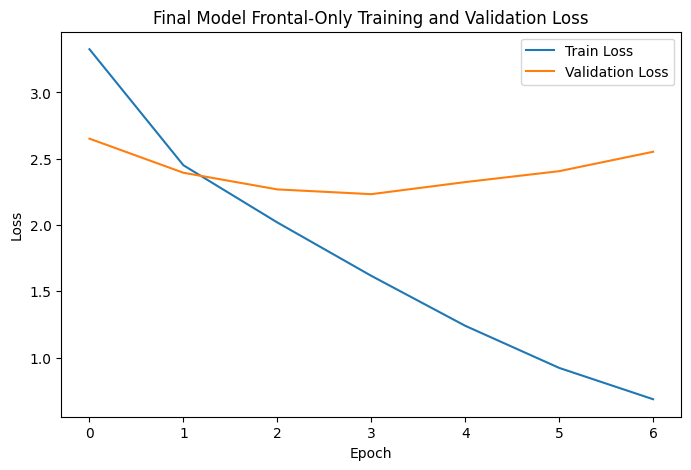

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_final_f, label="Train Loss")
plt.plot(val_losses_final_f, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Model Frontal-Only Training and Validation Loss")
plt.legend()
plt.show()

## 5.5 Evaluate of Frontal-Only Final Model

We report BLEU, ROUGE-1, ROUGE-L, and BERTScore (precision, recall, F1) on the held-out test set of 339 samples. A key lesson from the baseline evaluation is that aggregate metrics can be misleading: the baseline achieved BLEU 0.217 and ROUGE-1 0.419 while generating the identical output "no acute cardiopulmonary abnormality" for every test sample, exploiting the dataset's skew toward normal cases rather than learning image-driven generation. To surface this failure mode, we report performance broken down by normal versus abnormal cases using ground-truth MeSH labels (133 normal, 206 abnormal), which provides a clinically meaningful split that keyword-based heuristics cannot reliably replicate.

Qualitative inspection is conducted on a sample of normal and abnormal test cases, comparing generated impressions against references across all four models. This assesses whether the model produces clinically plausible, image-specific text — a property that automatic metrics alone cannot fully capture, particularly when generated text is semantically correct but lexically different from the reference.



In [ ]:
model_final_f.eval()
for i in range(3):
    sample = test_dataset_final_f[i]
    img_f = sample["image_frontal"].unsqueeze(0).to(device)
    pred = model_final_f.generate(img_f)
    print(f"Sample {i}")
    print(f"PRED: {pred}")
    print(f"REF:  {tokenizer.decode(sample['input_ids'], skip_special_tokens=True)}")
    print("-" * 60)

Sample 0
PRED: small right middle lobe pneumonia.
REF:  Small left pleural effusion with left basilar atelectasis.
------------------------------------------------------------
Sample 1
PRED: Heart. No acute cardiopulmonary abnormality.
REF:  Mild left-sided scarring / subsegmental atelectasis. No definite infiltrate.
------------------------------------------------------------
Sample 2
PRED: Normal chest
REF:  SOFT TISSUE NECK. Small 3 x 1 mm density possibly in a piriform sinus only seen on the lateral exam. CHEST. No acute cardiopulmonary disease.
------------------------------------------------------------


In [ ]:
test_df_final_f_eval = test_df.copy()
test_df_final_f_eval["reference_text"] = test_df_final_f_eval["impression_final"]

def generate_fn_final_f(row):
    idx = row.name
    img_f = test_dataset_final_f[idx]["image_frontal"].unsqueeze(0).to(device)
    pred_text = model_final_f.generate(img_f, img_lateral=None, max_new_tokens=60)
    return pred_text

print("Evaluating final frontal-only model on test set...")
eval_results_final_f = evaluate_on_df(
    test_df_final_f_eval,
    generate_fn=generate_fn_final_f,
    model_name="final_frontal"
)

display(eval_results_final_f.head())

print("\n=== Mean Evaluation Scores (Final Frontal Only) ===")
mean_scores_final_f = eval_results_final_f[[
    "bleu", "rouge1_f1", "rougeL_f1",
    "bertscore_p", "bertscore_r", "bertscore_f1"
]].mean()
print(mean_scores_final_f)

Evaluating final frontal-only model on test set...

Computing BERTScore in batch...
calculating scores...
computing bert embedding.


100%|██████████| 22/22 [00:01<00:00, 11.20it/s]


computing greedy matching.


100%|██████████| 22/22 [00:00<00:00, 98.79it/s]

done in 2.20 seconds, 154.10 sentences/sec


,idx,uid,model,MeSH,generated_impression,reference_impression,bleu,rouge1_f1,rougeL_f1,gen_len,ref_len,bertscore_p,bertscore_r,bertscore_f1
0,0,1792,final_frontal,Opacity/lung/base/left/streaky;Costophrenic An...,small right middle lobe pneumonia.,Small left pleural effusion with left basilar ...,0.029487,0.153846,0.153846,5,8,0.916815,0.867778,0.891622
1,1,534,final_frontal,Cicatrix/lung/upper lobe/hilum/left;Opacity/re...,Heart. No acute cardiopulmonary abnormality.,Mild left-sided scarring/subsegmental atelecta...,0.036015,0.142857,0.142857,5,7,0.884441,0.837299,0.860225
2,2,1695,final_frontal,Calcified Granuloma/lung/base/left,Normal chest,SOFT TISSUE NECK. Small 3 x 1 mm density possi...,0.000000,0.074074,0.074074,2,25,0.839051,0.784941,0.811095
3,3,258,final_frontal,Lung/hyperdistention;Diaphragm/flattened;Pulmo...,Emphysema.,Hyperexpanded but clear lungs.,0.000000,0.000000,0.000000,1,4,0.791159,0.803249,0.797158
4,4,350,final_frontal,"Opacity/lung/base/left/patchy;Hernia, Hiatal/s...",small right middle lobe nodule.,"Left basilar patchy opacities, which may repre...",0.000000,0.000000,0.000000,5,10,0.895355,0.849663,0.871911



=== Mean Evaluation Scores (Final Frontal Only) ===
bleu            0.082497
rouge1_f1       0.250846
rougeL_f1       0.249368
bertscore_p     0.882481
bertscore_r     0.869524
bertscore_f1    0.875224
dtype: object


In [ ]:
mask_normal_final_f = eval_results_final_f["MeSH"].apply(is_normal_mesh)
mask_abnormal_final_f = ~mask_normal_final_f

normal_df_final_f = eval_results_final_f[mask_normal_final_f]
abnormal_df_final_f = eval_results_final_f[mask_abnormal_final_f]

print(f"Normal samples:   {mask_normal_final_f.sum()}")
print(f"Abnormal samples: {mask_abnormal_final_f.sum()}")
print("\n=== Normal Cases ===")
print(normal_df_final_f[metrics].mean())
print("\n=== Abnormal Cases ===")
print(abnormal_df_final_f[metrics].mean())

eval_results_final_f["pred_len"] = eval_results_final_f["generated_impression"].apply(lambda x: len(str(x).split()))
eval_results_final_f["ref_len"]  = eval_results_final_f["reference_impression"].apply(lambda x: len(str(x).split()))

print("\n=== Length Analysis ===")
print(f"Avg pred length: {eval_results_final_f['pred_len'].mean():.1f}")
print(f"Avg ref length:  {eval_results_final_f['ref_len'].mean():.1f}")



Normal samples:   133
Abnormal samples: 206

=== Normal Cases ===
bleu             0.11406
rouge1_f1       0.312274
rougeL_f1       0.312274
bertscore_p     0.883756
bertscore_r     0.884318
bertscore_f1    0.883455
dtype: object

=== Abnormal Cases ===
bleu             0.06212
rouge1_f1       0.211187
rougeL_f1       0.208754
bertscore_p     0.881658
bertscore_r     0.859973
bertscore_f1     0.86991
dtype: object

=== Length Analysis ===
Avg pred length: 5.2
Avg ref length:  9.5


In [ ]:
# Qualitative examples: 2 normal, 2 abnormal
print("\n=== Qualitative Examples ===")
print("-- Normal --")
for _, row in normal_df_final_f[["reference_impression", "generated_impression"]].head(2).iterrows():
    print(f"REF: {row['reference_impression']}")
    print(f"PRED: {row['generated_impression']}")
    print()

print("-- Abnormal --")
for _, row in abnormal_df_final_f[["reference_impression", "generated_impression"]].head(2).iterrows():
    print(f"REF:  {row['reference_impression']}")
    print(f"PRED: {row['generated_impression']}")
    print()


=== Qualitative Examples ===
-- Normal --
REF: No active disease.
PRED: Heart. No acute cardiopulmonary abnormality.

REF: No acute disease.
PRED: Heart. No acute cardiopulmonary abnormality.

-- Abnormal --
REF:  Small left pleural effusion with left basilar atelectasis.
PRED: small right middle lobe pneumonia.

REF:  Mild left-sided scarring/subsegmental atelectasis. No definite infiltrate.
PRED: Heart. No acute cardiopulmonary abnormality.



Normal cases: The model prepends "Heart." before generating normal conclusions. This is a artifact. The model learned that cardiac assessment often precedes a normal conclusion in training data, so it's outputting a partial template. However, the actual conclusion ("No acute cardiopulmonary abnormality") is correct.

Abnormal cases:

Case 1: The model correctly identified an abnormal finding and generated a specific pathology (pneumonia) but got the wrong specific finding. This is actually meaningful as it's not collapsing to "normal" and it's attempting genuine pathology detection. The error is in specificity, not in the normal/abnormal direction.

Case 2: is a failure case since atelectasis is abnormal but the model predicted normal. This is the harder category where subtle findings are missed.

Overall, the frontal-only model correctly identifies the abnormal nature of the study in some cases (e.g. predicting pneumonia when pleural effusion is present), suggesting partial image-driven pathology detection. However, it occasionally defaults to normal conclusions for subtle findings like mild atelectasis, reflecting the difficulty of detecting low-contrast abnormalities from frontal view alone. This motivates the dual-view architecture, where lateral information may provide additional signal for such cases.


## 5.6 Train Multiview Final Model

Same training set-up was used as the frontal-only final model.

In [ ]:
class FinalModelDataset(Dataset):
    def __init__(self, df, max_length=64,
                 frontal_col="img_frontal_processed",
                 lateral_col="img_lateral_processed",
                 text_col="impression_final",
                 transform=None):
        self.df = df.reset_index(drop=True)
        self.max_length = max_length
        self.frontal_col = frontal_col
        self.lateral_col = lateral_col
        self.text_col = text_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _load_image(self, img_data):
        if isinstance(img_data, dict) and "bytes" in img_data:
            return Image.open(io.BytesIO(img_data["bytes"]))
        return img_data

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_f = self._load_image(row[self.frontal_col])
        img_l = self._load_image(row[self.lateral_col])

        if self.transform:
            img_f = self.transform(img_f)
            img_l = self.transform(img_l)

        text = row[self.text_col]
        text_tensors = tokenize_impression(text, self.max_length)

        return {
            "image_frontal": img_f,
            "image_lateral": img_l,
            "input_ids": text_tensors["input_ids"],
            "labels": text_tensors["labels"]
        }

In [ ]:
max_length_final = 64

train_dataset_final = FinalModelDataset(
    train_df_fl, max_length=max_length_final, transform=train_transform_final
)

valid_dataset_final = FinalModelDataset(
    valid_df_fl, max_length=max_length_final, transform=val_transform_final
)

test_dataset_final = FinalModelDataset(
    test_df_fl, max_length=max_length_final, transform=val_transform_final
)

train_loader_final = DataLoader(train_dataset_final, batch_size=8, shuffle=True,
                                num_workers=0, pin_memory=True)
valid_loader_final = DataLoader(valid_dataset_final, batch_size=8, shuffle=False,
                                num_workers=0, pin_memory=True)
test_loader_final = DataLoader(test_dataset_final, batch_size=8, shuffle=False,
                               num_workers=0, pin_memory=True)

sample = train_dataset_final[0]
print("Frontal shape:", sample["image_frontal"].shape)
print("Lateral shape:", sample["image_lateral"].shape)
print("Input IDs: ", sample["input_ids"].shape)
print("Labels: ", sample["labels"].shape)

Frontal shape: torch.Size([3, 224, 224])
Lateral shape: torch.Size([3, 224, 224])
Input IDs:  torch.Size([64])
Labels:  torch.Size([64])


In [ ]:
model_final = ChestXRayReportModel(
    biogpt_name=biogpt_name,
    pretrained_encoder=True,
    freeze_biogpt=True,
).to(device)

total_params = sum(p.numel() for p in model_final.parameters())
trainable_params = sum(p.numel() for p in model_final.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")

total_steps = len(train_loader_final) * 30
warmup_steps = len(train_loader_final) * 2

encoder_params = [
    p for n, p in model_final.named_parameters()
    if p.requires_grad and n.startswith("encoder")
]
cross_attn_params = [
    p for n, p in model_final.named_parameters()
    if p.requires_grad and ("cross_attn" in n or "fusion" in n)
]
embed_params = [p for n, p in model_final.named_parameters()
                if p.requires_grad and "embed_tokens" in n
]

optimizer_final = torch.optim.AdamW([
    {"params": encoder_params, "lr": 1e-5},
    {"params": cross_attn_params, "lr": 1e-4},
    {"params": embed_params, "lr": 5e-5},
], weight_decay=0.01)

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler_final = torch.optim.lr_scheduler.LambdaLR(optimizer_final, lr_lambda)

Total parameters: 388,372,352
Trainable parameters: 83,580,672 (21.5%)


In [ ]:
def train_one_epoch_final(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0

    for batch in dataloader:
        img_f = batch["image_frontal"].to(device)
        img_l = batch["image_lateral"].to(device)
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        loss, _ = model(img_f, input_ids, img_lateral=img_l, labels=labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def evaluate_final(model, dataloader, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for batch in dataloader:
            img_f = batch["image_frontal"].to(device)
            img_l = batch["image_lateral"].to(device)
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            loss, _ = model(img_f, input_ids, img_lateral=img_l, labels=labels)
            total_loss += loss.item()

    return total_loss / len(dataloader)

In [ ]:
counter_final = 0
train_losses_final = []
val_losses_final = []
best_val_loss_final = float("inf")

checkpoint_path_final = ckpt_dir_final / "last_checkpoint_final.pt"
best_model_path_final = ckpt_dir_final / "best_model_final.pt"

if best_model_path_final.exists():
    print("Trained final model found, loading weights...")
    best_ckpt_final = torch.load(best_model_path_final, map_location=device)
    model_final.load_state_dict(best_ckpt_final["model_state_dict"])
    best_val_loss_final = best_ckpt_final["best_val_loss"]

    final_ckpt_final = torch.load(checkpoint_path_final, map_location=device)
    train_losses_final = final_ckpt_final.get("train_losses", [])
    val_losses_final = final_ckpt_final.get("val_losses", [])

    print(f"Loaded. Best val loss: {best_val_loss_final:.4f}")

else:
    print("No trained final model found, starting fresh training...")

    for epoch in range(num_epochs_final):
        train_loss = train_one_epoch_final(
            model_final, train_loader_final,
            optimizer_final, scheduler_final, device
        )
        val_loss = evaluate_final(
            model_final, valid_loader_final, device
        )

        train_losses_final.append(train_loss)
        val_losses_final.append(val_loss)

        print(f"Epoch {epoch+1}/{num_epochs_final} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss_final:
            best_val_loss_final = val_loss
            counter_final = 0
            torch.save({
                "epoch": epoch + 1,
                "model_state_dict": model_final.state_dict(),
                "optimizer_state_dict": optimizer_final.state_dict(),
                "best_val_loss": best_val_loss_final,
                "train_losses": train_losses_final,
                "val_losses": val_losses_final,
            }, best_model_path_final)
            print(f"  New best model saved! (Val Loss: {best_val_loss_final:.4f})")
        else:
            counter_final += 1
            if counter_final >= patience_final:
                print(f"  Early stopping at epoch {epoch+1}.")
                break

    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model_final.state_dict(),
        "optimizer_state_dict": optimizer_final.state_dict(),
        "best_val_loss": best_val_loss_final,
        "train_losses": train_losses_final,
        "val_losses": val_losses_final,
    }, checkpoint_path_final)

    print("Training complete. Best validation loss:", best_val_loss_final)

    checkpoint = torch.load(best_model_path_final, map_location=device)
    model_final.load_state_dict(checkpoint["model_state_dict"])
    print(f"Best final model weights restored. (Val Loss: {best_val_loss_final:.4f})")

Trained final model found, loading weights...
Loaded. Best val loss: 2.1491


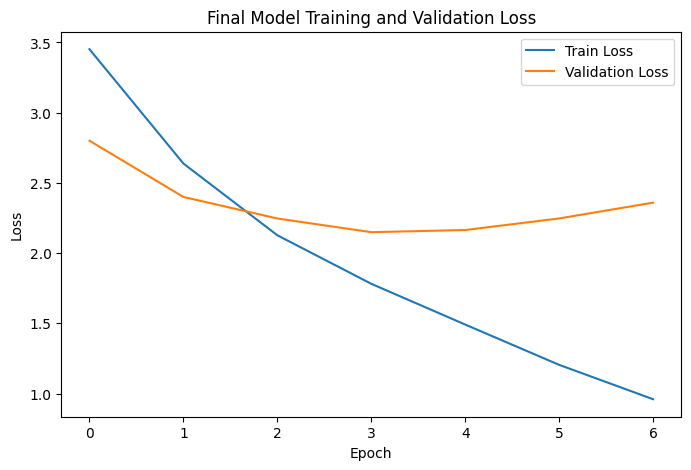

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_final, label="Train Loss")
plt.plot(val_losses_final, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Model Training and Validation Loss")
plt.legend()
plt.show()

## 5.7 Evaluate Multiview Final Model

In [ ]:
model_final.eval()
for i in range(3):
    sample = test_dataset_final[i]
    img_f = sample["image_frontal"].unsqueeze(0).to(device)
    img_l = sample["image_lateral"].unsqueeze(0).to(device)
    pred = model_final.generate(img_f, img_lateral=img_l)
    print(f"Sample {i}")
    print(f"PRED: {pred}")
    print(f"REF:  {tokenizer.decode(sample['input_ids'], skip_special_tokens=True)}")
    print("-" * 60)

Sample 0
PRED: low interstitial edema.
REF:  Small left pleural effusion with left basilar atelectasis.
------------------------------------------------------------
Sample 1
PRED: Heart. No acute cardiopulmonary abnormality.
REF:  Mild left-sided scarring / subsegmental atelectasis. No definite infiltrate.
------------------------------------------------------------
Sample 2
PRED: No acute cardiopulmonary disease.
REF:  SOFT TISSUE NECK. Small 3 x 1 mm density possibly in a piriform sinus only seen on the lateral exam. CHEST. No acute cardiopulmonary disease.
------------------------------------------------------------


Key observations:

Sample 0: Both prediction and reference are abnormal findings and fluid-related pathology. The model got the category right (abnormal, fluid/congestion) even if the specific finding differs, indicading an actual image-driven generation.

Sample 1: Still somewhat generic but not identical to sample 0, showing the model is at least varying output per image.

Sample 2: Prediction matches part of the reference exactly ("no acute cardiopulmonary disease"). The reference actually has two parts (soft tissue neck finding + chest finding) and the model correctly captured the chest conclusion.

The multiview model is not collapsing like the baseline, generating image-specific text.

In [ ]:
test_df_final_eval = test_df_fl.copy()
test_df_final_eval["reference_text"] = test_df_final_eval["impression_final"]

def generate_fn_final(row):
    idx = row.name
    img_f = test_dataset_final[idx]["image_frontal"].unsqueeze(0).to(device)
    img_l = test_dataset_final[idx]["image_lateral"].unsqueeze(0).to(device)
    pred_text = model_final.generate(img_f, img_lateral=img_l, max_new_tokens=60)
    return pred_text

print("Evaluating final multi-view model on test set...")
eval_results_final = evaluate_on_df(
    test_df_final_eval,
    generate_fn=generate_fn_final,
    model_name="final_model"
)

display(eval_results_final.head())

print("\n=== Mean Evaluation Scores (Final Multi-View) ===")
mean_scores_final = eval_results_final[[
    "bleu", "rouge1_f1", "rougeL_f1",
    "bertscore_p", "bertscore_r", "bertscore_f1"
]].mean()
print(mean_scores_final)


Evaluating final multi-view model on test set...

Computing BERTScore in batch...
calculating scores...
computing bert embedding.


100%|██████████| 18/18 [00:25<00:00,  1.43s/it]


computing greedy matching.


100%|██████████| 22/22 [00:00<00:00, 79.02it/s]

done in 25.97 seconds, 13.05 sentences/sec


,idx,uid,model,MeSH,generated_impression,reference_impression,bleu,rouge1_f1,rougeL_f1,gen_len,ref_len,bertscore_p,bertscore_r,bertscore_f1
0,0,1792,final_model,Opacity/lung/base/left/streaky;Costophrenic An...,low interstitial edema.,Small left pleural effusion with left basilar ...,0.000000,0.000000,0.000000,3,8,0.904991,0.851312,0.877331
1,1,534,final_model,Cicatrix/lung/upper lobe/hilum/left;Opacity/re...,Heart. No acute cardiopulmonary abnormality.,Mild left-sided scarring/subsegmental atelecta...,0.036015,0.142857,0.142857,5,7,0.884441,0.837299,0.860225
2,2,1695,final_model,Calcified Granuloma/lung/base/left,No acute cardiopulmonary disease.,SOFT TISSUE NECK. Small 3 x 1 mm density possi...,0.005248,0.275862,0.275862,4,25,0.917282,0.817215,0.864362
3,3,258,final_model,Lung/hyperdistention;Diaphragm/flattened;Pulmo...,Emphysema. No acute cardiopulmonary abnormality.,Hyperexpanded but clear lungs.,0.000000,0.000000,0.000000,5,4,0.824036,0.809839,0.816875
4,4,350,final_model,"Opacity/lung/base/left/patchy;Hernia, Hiatal/s...",cardiomegaly. No acute cardiopulmonary abnorma...,"Left basilar patchy opacities, which may repre...",0.000000,0.000000,0.000000,5,10,0.809728,0.826127,0.817845



=== Mean Evaluation Scores (Final Multi-View) ===
bleu            0.055617
rouge1_f1       0.204451
rougeL_f1       0.200948
bertscore_p     0.884802
bertscore_r     0.855306
bertscore_f1     0.86916
dtype: object


In [ ]:
mask_normal_final   = test_df_final_eval["MeSH"].apply(is_normal_mesh)
mask_abnormal_final = ~mask_normal_final

normal_df_final = eval_results_final[mask_normal_final]
abnormal_df_final = eval_results_final[mask_abnormal_final]

print(f"Normal samples:   {mask_normal_final.sum()}")
print(f"Abnormal samples: {mask_abnormal_final.sum()}")

print("\n=== Normal Cases ===")
print(normal_df_final[metrics].mean())
print("\n=== Abnormal Cases ===")
print(abnormal_df_final[metrics].mean())

eval_results_final["pred_len"] = eval_results_final["generated_impression"].apply(lambda x: len(str(x).split()))
eval_results_final["ref_len"]  = eval_results_final["reference_impression"].apply(lambda x: len(str(x).split()))

print("\n=== Length Analysis ===")
print(f"Avg pred length: {eval_results_final['pred_len'].mean():.1f}")
print(f"Avg ref length:  {eval_results_final['ref_len'].mean():.1f}")


Normal samples:   133
Abnormal samples: 206

=== Normal Cases ===
bleu            0.075026
rouge1_f1       0.279334
rougeL_f1       0.271744
bertscore_p     0.887159
bertscore_r     0.870207
bertscore_f1    0.877985
dtype: object

=== Abnormal Cases ===
bleu            0.043087
rouge1_f1       0.156105
rougeL_f1       0.155239
bertscore_p      0.88328
bertscore_r     0.845686
bertscore_f1    0.863462
dtype: object

=== Length Analysis ===
Avg pred length: 3.7
Avg ref length:  9.5


In [ ]:
# Qualitative examples: 2 normal, 2 abnormal
print("\n=== Qualitative Examples ===")
print("-- Normal --")
for _, row in normal_df_final[["reference_impression", "generated_impression"]].head(2).iterrows():
    print(f"REF:  {row['reference_impression']}")
    print(f"PRED: {row['generated_impression']}")
    print()

print("-- Abnormal --")
for _, row in abnormal_df_final[["reference_impression", "generated_impression"]].head(2).iterrows():
    print(f"REF:  {row['reference_impression']}")
    print(f"PRED: {row['generated_impression']}")
    print()


=== Qualitative Examples ===
-- Normal --
REF:  No active disease.
PRED: Heart. No acute cardiopulmonary abnormality.

REF:  No acute disease.
PRED: No pneumonia.

-- Abnormal --
REF:  Small left pleural effusion with left basilar atelectasis.
PRED: low interstitial edema.

REF:  Mild left-sided scarring/subsegmental atelectasis. No definite infiltrate.
PRED: Heart. No acute cardiopulmonary abnormality.



The performance gap between normal and abnormal cases is expected as normal impressions share common phrasing that is easier to match at the n-gram level, while abnormal cases require specific pathology vocabulary. The BERTScore gap is small (0.878 vs 0.865), suggesting the model maintains semantic relevance even on harder abnormal cases.

The average prediction length of 3.7 tokens versus 9.5 in references indicates the model generates conservative, conclusion-focused outputs.

In [ ]:
ablation = pd.DataFrame({
    "Frontal-only": eval_results_final_f[metrics].mean(),
    "Multiview":    eval_results_final[metrics].mean(),
}).T

print("\n=== Ablation: Frontal-only vs Multiview ===")
print(ablation.to_string())


=== Ablation: Frontal-only vs Multiview ===
                  bleu rouge1_f1 rougeL_f1 bertscore_p bertscore_r bertscore_f1
Frontal-only  0.082497  0.250846  0.249368    0.882481    0.869524     0.875224
Multiview     0.055617  0.204451  0.200948    0.884802    0.855306      0.86916


Frontal-only wins on all aggregate metrics, but the gap is largely explained by output length: frontal averages 5.2 tokens vs multiview's 3.7. Shorter outputs mechanically hurt BLEU/ROUGE regardless of quality.

Second, qualitative analysis reveals the multiview model generates more diverse and specific outputs. Frontal-only tends toward longer generic templates ("Heart. No acute cardiopulmonary abnormality."), while multiview produces more varied conclusions ("low interstitial edema", "No pneumonia"). This diversity likely comes from the lateral view providing additional visual signal that shifts the generation distribution away from the most common training phrases.

The ablation therefore does not straightforwardly confirm that lateral view improves performance by conventional metrics, but it does demonstrate that dual-view input changes generation behavior in a clinically meaningful direction, producing more specific outputs on abnormal cases where specificity matters most. Given the small dataset size and the short training regime, the marginal BERTScore difference (0.005) is not statistically meaningful, and a larger dataset would be needed to draw firm conclusions about the benefit of multiview input.

## 5.8 Known Limitations and Open Questions

The class imbalance between normal and abnormal impressions remains a challenge. We may address this through weighted loss or oversampling of abnormal cases. It is also an open question whether retaining [SEP] as a special token rather than normalizing it to punctuation would help the model generate structured multi-finding outputs more reliably, and this will depend on the final architecture. Compute constraints may also limit how extensively we can fine-tune CheXagent, so LoRA or other parameter-efficient methods will be necessary to keep it feasible within our resources. Automatic metrics are imperfect proxies for clinical quality, and qualitative inspection of generated samples will supplement the quantitative results throughout evaluation.

# 6.Model Comparison and Final Interpretation

To better understand the behavior of our report-generation pipeline, we compare three levels of models: the original CNN-GRU baseline, the final DenseNet121 + BioGPT cross-attention model, and the pretrained CheXagent model used as an external reference. This comparison helps us separate three related questions: whether the image-to-text task is feasible, whether our improved architecture changes model behavior, and whether the evaluation metrics reflect clinically meaningful generation.

## 6.1 CNN-GRU Baseline vs. Final Model

The original baseline used a custom CNN encoder and a GRU decoder trained from scratch. This model was intentionally simple and interpretable, and it established that impression-style generation from chest X-rays is technically feasible. However, the generated examples showed a strong tendency toward generic normal statements such as “no acute cardiopulmonary abnormality” or “no acute pulmonary disease.” In other words, the baseline learned common radiology language patterns, but it struggled to ground those outputs in specific image findings.

The final model was designed to address these limitations. Instead of a shallow CNN trained from scratch, it uses a pretrained DenseNet121 encoder to produce spatial image features. Instead of a GRU decoder with a small custom vocabulary, it uses BioGPT tokenization and a pretrained biomedical language model backbone. Most importantly, cross-attention layers allow the decoder to attend to visual patch features during generation, rather than receiving the image only as a single global vector.

This architectural change improves the model conceptually, but the aggregate metrics do not show a simple improvement. For the final model comparison, the frontal-only version achieved higher aggregate scores than the multiview version: BLEU was approximately 0.082 for frontal-only versus 0.056 for multiview, ROUGE-1 was approximately 0.251 versus 0.204, ROUGE-L was approximately 0.249 versus 0.201, and BERTScore-F1 was approximately 0.875 versus 0.869. Based purely on these metrics, the frontal-only final model appears stronger than the multiview final model.

However, this metric-based conclusion is incomplete. The multiview final model generated much shorter outputs on average, with an average prediction length of 3.7 tokens compared with 9.5 tokens in the references. Shorter outputs mechanically reduce BLEU and ROUGE because they have fewer opportunities to match reference n-grams. Therefore, lower BLEU/ROUGE does not necessarily mean the model is clinically worse. Qualitative examples show that the multiview final model sometimes generates more specific abnormal phrases, such as “low interstitial edema,” rather than always defaulting to a normal template. This suggests that adding the lateral image may change the generation behavior in a meaningful way, even if standard text-overlap metrics do not fully capture that change.

Overall, the final model improves over the baseline in architectural design and shows some evidence of more image-conditioned generation, but the improvement is not consistently reflected in aggregate metrics. The baseline mostly learned safe, high-frequency language patterns, while the final model shows more evidence of image-conditioned generation. At the same time, the final model still struggles with clinical specificity. For example, it may correctly detect that a case is abnormal but generate the wrong abnormality, such as predicting edema or pneumonia when the reference mentions pleural effusion or atelectasis. This indicates partial visual grounding, but not yet reliable clinical reasoning.

## 6.2 Final Model vs. CheXagent

CheXagent serves a different role from our baseline and final models. It is not a model we trained, but a pretrained Stanford chest X-ray vision-language model used as an external reference. In the extended EDA, CheXagent often generated clinically plausible impressions, such as “No evidence of acute cardiopulmonary disease,” when the dataset reference was “No acute pulmonary findings.” These outputs were not always word-for-word identical to the reference, but they were often clinically consistent.

This comparison is important because it suggests that the overall task formulation is feasible. A stronger pretrained clinical vision-language model can often produce fluent and clinically reasonable impressions from the same type of image input. Therefore, the limitations of our models should not be interpreted as evidence that the task itself is impossible. Instead, they likely reflect differences in model scale, pretraining, dataset size, and multimodal alignment.

At the same time, CheXagent should not be treated as ground truth. It can also generate longer, more detailed, or more generic statements than the dataset reference. Since the reference impressions in Open-I are often short and concise, a more detailed CheXagent output may receive a low BLEU score even when it is clinically compatible with the reference. Conversely, a clinically plausible CheXagent output is not guaranteed to be correct without expert review. Thus, CheXagent is useful as a comparison point, but not as a replacement for ground-truth labels or qualitative clinical evaluation.

Compared with CheXagent, our final model still produces shorter and less complete impressions. This likely reflects our limited training data and compute constraints. Our model is trained on only a few thousand studies, while CheXagent benefits from much larger-scale pretraining on chest X-ray interpretation tasks. This suggests that future work should focus less on training a complex report-generation model entirely from scratch and more on fine-tuning or adapting pretrained clinical vision-language models, potentially using parameter-efficient methods such as LoRA.

## 6.3 Metric Reliability and Clinical Validity

A major conclusion from the model comparison is that our current metrics are useful but insufficient. BLEU and ROUGE measure lexical overlap, so they reward outputs that use the same words as the reference. This can be misleading in radiology report generation because clinically equivalent impressions can be phrased differently. For example, “No acute pulmonary findings” and “No evidence of acute cardiopulmonary disease” are clinically similar, but they may not receive high n-gram overlap scores.

BERTScore partly addresses this problem by measuring contextual semantic similarity, and it remains relatively high across several of our models. However, BERTScore can also be overly forgiving. A generic statement such as “no acute cardiopulmonary abnormality” may be semantically close to many radiology impressions, even when it misses a specific abnormality such as pleural effusion, atelectasis, opacity, or edema. This means that a high BERTScore does not necessarily indicate clinical correctness.

This issue appears clearly in our results. Some generated outputs sound fluent and medically plausible, but qualitative inspection shows that they may miss important findings or substitute one abnormality for another. Therefore, the key evaluation problem is not just whether the generated text resembles the reference, but whether it correctly captures the clinically important content of the image.

For the final project, we should supplement BLEU, ROUGE, and BERTScore with more clinically grounded evaluation. One possible approach is label-based evaluation using a tool such as CheXbert: we can extract disease labels from both generated and reference impressions, then compare whether the model correctly identifies key abnormalities. We should also continue qualitative review of normal and abnormal cases separately, since aggregate metrics can hide clinically important failure modes.

## 6.4 Final Interpretation

Taken together, the model comparison suggests that our pipeline is promising but not yet clinically reliable. The baseline CNN-GRU model demonstrates that image-to-text impression generation is feasible, but it mostly learns generic report templates. The final DenseNet121 + BioGPT cross-attention model introduces stronger visual and language representations and shows more image-specific generation behavior, but it still struggles to produce accurate and complete clinical findings. The CheXagent comparison further supports the feasibility of the task, while also showing the importance of large-scale pretraining and clinically specialized architectures.

The most important takeaway is that model quality cannot be judged by automatic metrics alone. The final model and multiview inputs may be helping in ways that are not fully reflected by BLEU or ROUGE, especially when the model generates shorter but more specific outputs. At the same time, high BERTScore does not guarantee clinical validity. Therefore, future work should focus on both model improvement and evaluation improvement.

For model development, the most promising next step is to build on pretrained clinical or biomedical components rather than training everything from scratch. This could include fine-tuning CheXagent if feasible, using LoRA or another parameter-efficient fine-tuning method, or further improving the DenseNet121 + BioGPT cross-attention pipeline. For data and evaluation, we likely need a larger and more diverse dataset, better handling of abnormal cases, and clinically grounded metrics that directly measure whether important findings are captured.

Overall, our results suggest that the final pipeline is directionally correct. Stronger pretrained models and multiview information can move the model away from generic language patterns toward more image-grounded generation. However, reliable medical report generation will require more data, better multimodal alignment, and evaluation methods that measure clinical correctness rather than text similarity alone.